# Análisis del impacto educacional del uso de IA

---

In [26]:
import os, sys
import polars as pl

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..', '..')

data_filename = 'processed_forms_interactions_data.parquet'
data_path = os.path.join(project_path, 'data', 'combined', data_filename)

sys.path.append(project_path)
from src.utils.educational_impact_analysis import (
    group_stats,
    plot_cat_distribution,
    plot_cat_comparison,
    plot_quant_distribution,
    plot_quant_comparison
)

forms_interactions_df = pl.read_parquet(data_path)


---

## Vista de la tabla

In [27]:
forms_interactions_df

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use,experimental_type_freq_quality,grupo_segmented
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool,str,str
"""RamiroMaeztu-ks0""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,"""Alto""","""Alto""","""Alto""",0.6,0.2,0.8,0.4,"""Medio""","""Bajo""","""Medio""","""Bajo""",1.0,0.4,1.0,1.0,"""Alto""","""Bajo""","""Medio""","""Alto""",0.8,0.43,0.27,"""Medio""","""Medio""","""Bajo""",2,5,true,true,true,"""Media""",1.5,"""Superficial""",false,"""BB""","""BB"""
"""RamiroMaeztu-pu9""","""RamiroMaeztu""","""experimental""",1.0,0.0,1.0,"""Alto""","""Bajo""","""Alto""",0.8,0.48,1.0,0.6,"""Alto""","""Medio""","""Alto""","""Medio""",1.0,0.55,1.0,1.0,"""Alto""","""Medio""","""Medio""","""Alto""",0.2,0.4,0.27,"""Bajo""","""Medio""","""Bajo""",8,5,false,true,true,"""Alta""",1.625,"""Superficial""",false,"""AB""","""AB"""
"""RamiroMaeztu-8jb""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,"""Alto""","""Alto""","""Alto""",0.6,0.45,0.6,0.6,"""Medio""","""Medio""","""Bajo""","""Medio""",1.0,0.4,1.0,1.0,"""Alto""","""Bajo""","""Medio""","""Alto""",0.57,0.6,0.47,"""Bajo""","""Alto""","""Medio""",7,5,true,true,true,"""Alta""",2.571429,"""Profunda""",true,"""AA""","""AA"""
"""RamiroMaeztu-x5e""","""RamiroMaeztu""","""experimental""",0.0,-2.0,0.667,"""Bajo""","""Bajo""","""Medio""",0.6,0.7,0.8,0.4,"""Medio""","""Alto""","""Medio""","""Bajo""",0.6,0.43,0.4,0.8,"""Bajo""","""Bajo""","""Bajo""","""Bajo""",0.63,0.53,0.63,"""Bajo""","""Alto""","""Alto""",0,5,false,false,true,"""No Usado""",null,null,false,"""BB""","""BB"""
"""RamiroMaeztu-80a""","""RamiroMaeztu""","""experimental""",0.5,0.0,0.5,"""Medio""","""Bajo""","""Medio""",0.8,0.52,1.0,0.6,"""Alto""","""Alto""","""Alto""","""Medio""",0.9,0.6,1.0,0.8,"""Medio""","""Alto""","""Medio""","""Bajo""",0.9,0.3,0.27,"""Alto""","""Medio""","""Bajo""",0,5,false,false,true,"""No Usado""",null,null,false,"""BB""","""BB"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Laguna-r45""","""Laguna""","""experimental""",0.0,-1.0,0.5,"""Bajo""","""Bajo""","""Medio""",0.7,0.35,0.8,0.6,"""Medio""","""Bajo""","""Medio""","""Medio""",0.7,0.6,0.6,0.8,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.63,0.47,0.43,"""Bajo""","""Medio""","""Medio""",3,5,true,true,true,"""Media""",1.333333,"""Superficial""",false,"""BB""","""BB"""
"""Laguna-lqw""","""Laguna""","""experimental""",0.4,0.5,0.333,"""Medio""","""Medio""","""Medio""",0.5,0.52,0.6,0.4,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.7,0.6,0.8,0.6,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.93,0.53,0.2,"""Alto""","""Alto""","""Bajo""",2,5,false,true,true,"""Media""",1.0,"""Superficial""",false,"""BB""","""BB"""
"""Laguna-chn""","""Laguna""","""experimental""",0.2,-2.0,0.75,"""Bajo""","""Bajo""","""Alto""",0.5,0.52,0.8,0.2,"""Bajo""","""Alto""","""Medio""","""Bajo""",0.6,0.58,0.4,0.8,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.93,0.27,0.33,"""Alto""","""Bajo""","""Medio""",4,5,false,

---

## Detección de inconsistencias

### Grupo Control/Experimental vs Métricas Herramienta

In [28]:
forms_interactions_df['grupo'].value_counts()

grupo,count
str,u32
"""experimental""",94
"""control""",97


In [29]:
forms_interactions_df['chat_freq_use'].value_counts()

chat_freq_use,count
str,u32
"""Baja""",9
"""Alta""",29
"""Media""",24
"""No Usado""",29
null,100


In [30]:
forms_interactions_df['chat_freq_use'].value_counts().filter(pl.col('chat_freq_use').is_null())['count'][0]

100

In [31]:
forms_interactions_df['grupo'].value_counts().filter(pl.col('grupo') == 'control')['count'][0]

97

Todos los de control tienen null en la herramienta? --> Si --> No problema



In [32]:
forms_interactions_df.filter(
    pl.col('grupo') == 'control',
    pl.col('chat_freq_use').is_not_null()
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use,experimental_type_freq_quality,grupo_segmented
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool,str,str


Hay alguno de experimental con null en la herramienta? --> Si --> Problema

In [33]:
forms_interactions_df.filter(
    pl.col('grupo') == 'experimental',
    pl.col('chat_freq_use').is_null()
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use,experimental_type_freq_quality,grupo_segmented
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool,str,str
"""JesusMaria-nre""","""JesusMaria""","""experimental""",-1.0,0.0,0.0,"""Bajo""","""Bajo""","""Bajo""",0.9,0.28,0.8,1.0,"""Alto""","""Bajo""","""Medio""","""Alto""",0.8,0.45,0.8,0.8,"""Medio""","""Bajo""","""Bajo""","""Bajo""",0.6,0.6,0.63,"""Bajo""","""Alto""","""Alto""",null,null,null,null,null,null,null,null,null,null,null
"""JesusMaria-3ci""","""JesusMaria""","""experimental""",0.0,-1.0,0.5,"""Bajo""","""Bajo""","""Medio""",0.7,0.48,0.8,0.6,"""Medio""","""Medio""","""Medio""","""Medio""",0.7,0.6,0.6,0.8,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.83,0.27,0.23,"""Medio""","""Bajo""","""Bajo""",null,null,null,null,null,null,null,null,null,null,null
"""JesusMaria-33y""","""JesusMaria""","""experimental""",-1.25,-3.0,-0.667,"""Bajo""","""Bajo""","""Bajo""",0.6,0.45,0.8,0.4,"""Medio""","""Medio""","""Medio""","""Bajo""",0.1,0.48,0.2,0.0,"""Bajo""","""Medio""","""Bajo""","""Bajo""",0.6,0.63,0.6,"""Bajo""","""Alto""","""Alto""",null,null,null,null,null,null,null,null,null,null,null


In [34]:
problematic_experimental_ids = forms_interactions_df.filter(
    pl.col('grupo') == 'experimental',
    pl.col('chat_freq_use').is_null()
)['id'].to_list()

---

## Valores únicos

In [35]:
for col in forms_interactions_df.columns:
    print(col.upper())
    display(forms_interactions_df[col].unique().to_list())
    print('-' * 100)

ID


['Laguna-o61',
 'JoseGarciaNieto-nnx',
 'JoseGarciaNieto-5r5',
 'RamiroMaeztu-qr3',
 'RamiroMaeztu-unc',
 'JoseGarciaNieto-78x',
 'JoseGarciaNieto-p5c',
 'RamiroMaeztu-ykt',
 'JesusMaria-tim',
 'JesusMaria-l57',
 'Laguna-wct',
 'JoseGarciaNieto-wba',
 'RamiroMaeztu-2rr',
 'JesusMaria-yxb',
 'RamiroMaeztu-z2k',
 'RamiroMaeztu-e6m',
 'RamiroMaeztu-sum',
 'RamiroMaeztu-9t2',
 'RamiroMaeztu-u9m',
 'RamiroMaeztu-ywi',
 'JoseGarciaNieto-wob',
 'JesusMaria-1qm',
 'JesusMaria-ub4',
 'RamiroMaeztu-4gj',
 'RamiroMaeztu-pu9',
 'RamiroMaeztu-59v',
 'JesusMaria-nre',
 'JesusMaria-yi0',
 'RamiroMaeztu-cpk',
 'JesusMaria-f6g',
 'JesusMaria-d01',
 'Laguna-k93',
 'Laguna-yp1',
 'Laguna-v6h',
 'Laguna-776',
 'Laguna-mzg',
 'Laguna-3dz',
 'Laguna-17x',
 'RamiroMaeztu-ks0',
 'RamiroMaeztu-scg',
 'RamiroMaeztu-fmv',
 'JesusMaria-hq8',
 'JesusMaria-64o',
 'JesusMaria-aue',
 'Laguna-yfr',
 'JesusMaria-fxv',
 'JesusMaria-f16',
 'RamiroMaeztu-g43',
 'RamiroMaeztu-hrf',
 'RamiroMaeztu-5p9',
 'JoseGarciaNieto-lp

----------------------------------------------------------------------------------------------------
CENTRO


['Laguna', 'JoseGarciaNieto', 'RamiroMaeztu', 'JesusMaria']

----------------------------------------------------------------------------------------------------
GRUPO


...

----------------------------------------------------------------------------------------------------
EXPERIMENTAL_TYPE_FREQ_QUALITY


['BB', None, 'BA', 'AA', 'AB']

----------------------------------------------------------------------------------------------------
GRUPO_SEGMENTED


['BA', 'control', None, 'AA', 'BB', 'AB']

----------------------------------------------------------------------------------------------------


---

## Descripción general

In [36]:
forms_interactions_df.describe()

statistic,id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use,experimental_type_freq_quality,grupo_segmented
str,str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,f64,str,f64,str,f64,str,str
"""count""","""191""","""191""","""191""",191.0,191.0,191.0,"""191""","""191""","""191""",191.0,191.0,191.0,191.0,"""191""","""191""","""191""","""191""",191.0,191.0,191.0,191.0,"""191""","""191""","""191""","""191""",191.0,191.0,191.0,"""191""","""191""","""191""",91.0,91.0,85.0,91.0,91.0,"""91""",62.0,"""62""",91.0,"""91""","""188"""
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""","""0""",100.0,100.0,106.0,100.0,100.0,"""100""",129.0,"""129""",100.0,"""100""","""3"""
"""mean""",null,null,null,0.312508,0.209445,0.417984,null,null,null,0.60733,0.438901,0.684817,0.529843,null,null,null,null,0.764921,0.504241,0.774869,0.754974,null,null,null,null,0.727016,0.403822,0.383194,null,null,null,2.516484,4.67033,0.505882,0.681319,0.934066,null,1.519886,null,0.197802,null,null
"""std""",null,null,null,0.632694,0.839672,0.507239,null,null,null,0.182234,0.128556,0.232447,0.218847,null,null,null,null,0.175843,0.117421,0.227103,0.207907,null,null,null,null,0.179405,0.215019,0.185973,null,null,null,2.583549,1.247709,null,null,null,null,0.547501,null,null,null,null
"""min""","""JesusMaria-1lv""","""JesusMaria""","""control""",-3.0,-4.0,-1.0,"""Alto""","""Alto""","""Alto""",0.2,0.12,0.0,0.0,"""Alto""","""Alto""","""Alto""","""Alto""",0.1,0.15,0.0,0.0,"""Alto""","""Alto""","""Bajo""","""Alto""",0.1,0.1,0.1,"""Alto""","""Alto""","""Alto""",0.0,0.0,0.0,0.0,0.0,"""Alta""",0.0,"""Intermedia""",0.0,"""AA""","""AA"""
"""25%""",null,null,null,0.0,0.0,0.0,null,null,null,0.5,0.35,0.6,0.4,null,null,null,null,0.7,0.43,0.6,0.6,null,null,null,null,0.63,0.23,0.23,null,null,null,0.0,5.0,null,null,null,null,1.0,null,null,null,null
"""50%""",null,null,null,0.5,0.0,0.5,null,null,null,0.6,0.45,0.8,0.6,null,null,null,null,0.8,0.5,0.8,0.8,null,null,null,null,0.73,0.37,0.37,null,null,null,2.0,5.0,null,null,null,null,1.6,null,null,null,null
"""75%""",null,null,null,0.714,1.0,0.8,null,null,null,0.7,0.52,0.8,0.6,null,null,null,null,0.9,0.6,1.0,1.0,null,null,null,null,0.87,0.53,0.5,null,null,null,4.0,5.0,null,null,null,null,2.0,null,null,null,null
"""max""","""RamiroMaeztu-zhk""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,"""Medio""","""Medio""","""Medio""",1.0,0.7,1.0,1.0,"""Medio""","""Medio""","""Medio""","""Medio""",1.0,0.7,1.0,1.0,"""Medio""","""Medio""","""Medio""","""Bajo""",1.0,1.0,1.0,"""Medio""","""Medio""","""Medio""",12.0,5.0,1.0,1.0,1.0,"""No Usado""",3.0,"""Superficial""",1.0,"""BB""","""control"""


---

## Visualización de resultados


In [37]:
quant_cols = [col for col, type in zip(forms_interactions_df.columns, forms_interactions_df.dtypes) if type in [pl.Float64, pl.Int64]] 
cat_cols = [col for col in forms_interactions_df.columns if col not in quant_cols]

### Variables de contexto

In [38]:
context_cols = ['centro', 'grupo']

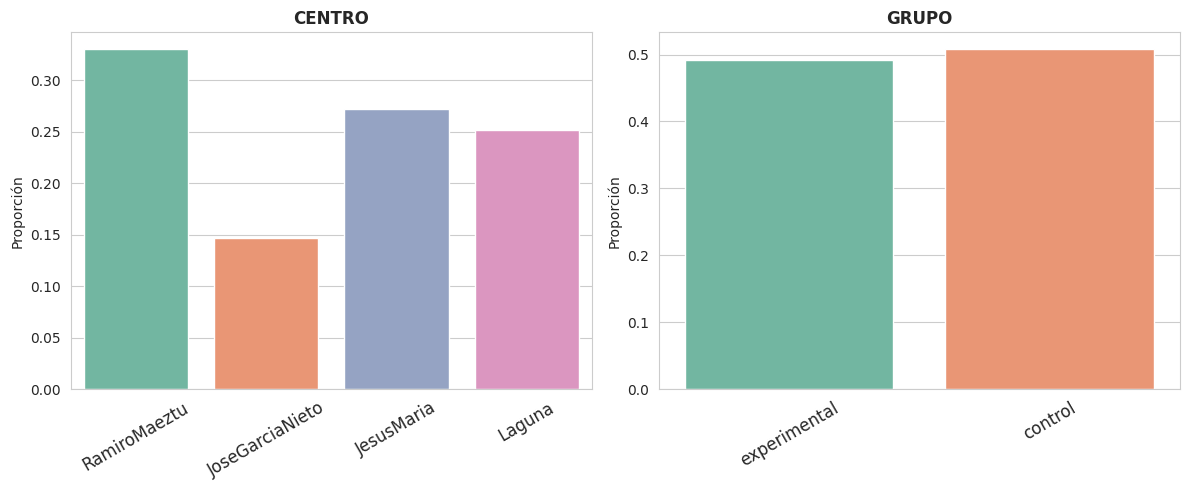

In [39]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = context_cols, 
    max_cols=3, 
    palette="Set2",
)

### Métricas de rendimiento

In [40]:
forms_cols = [col for col in forms_interactions_df.columns if 'puntuacion' in col]
forms_quant_cols = [col for col in forms_cols if col in quant_cols]
forms_cat_cols = [col for col in forms_cols if col in cat_cols]

#### TC-Hake

In [41]:
analysis_quant_cols = [col for col in forms_quant_cols if 'hake' in col]
analysis_cat_cols = [col for col in forms_cat_cols if 'hake' in col]

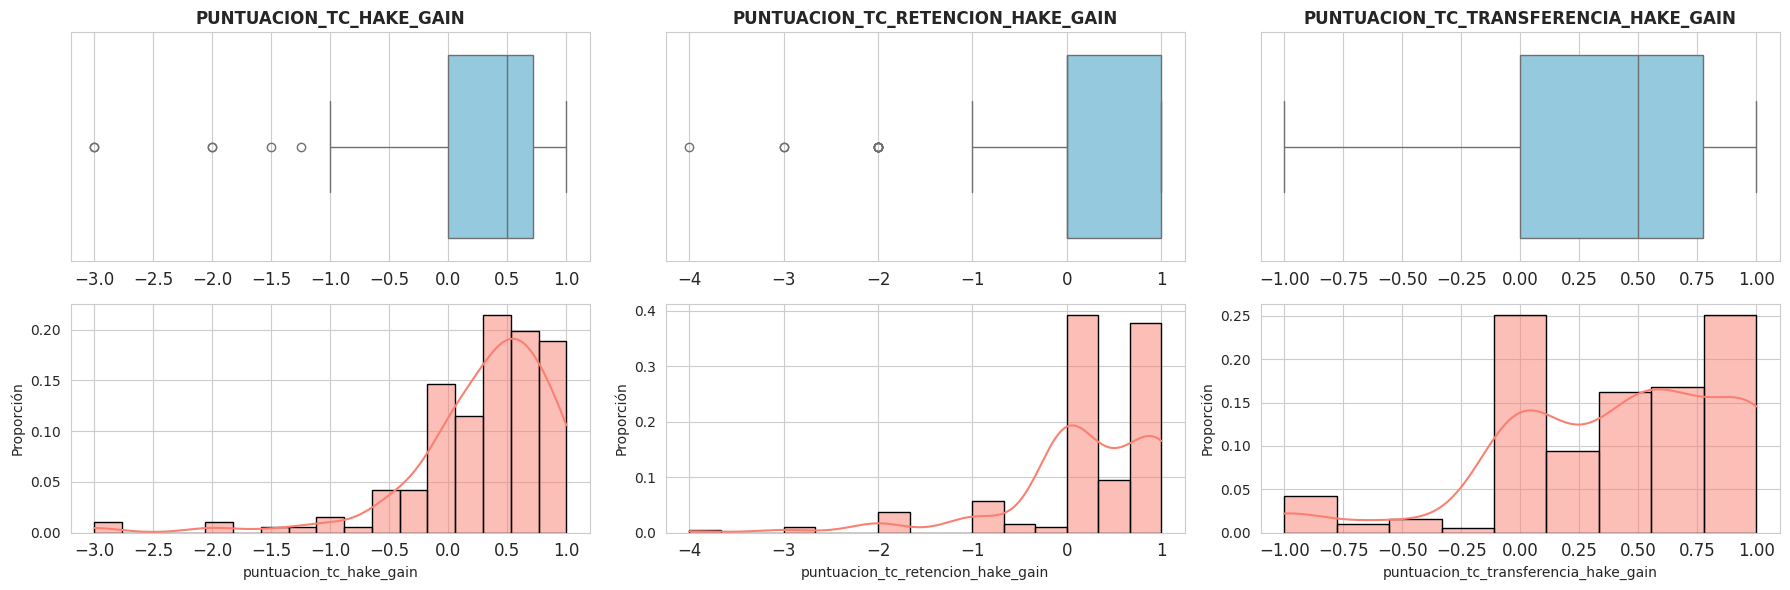

In [42]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = analysis_quant_cols, 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

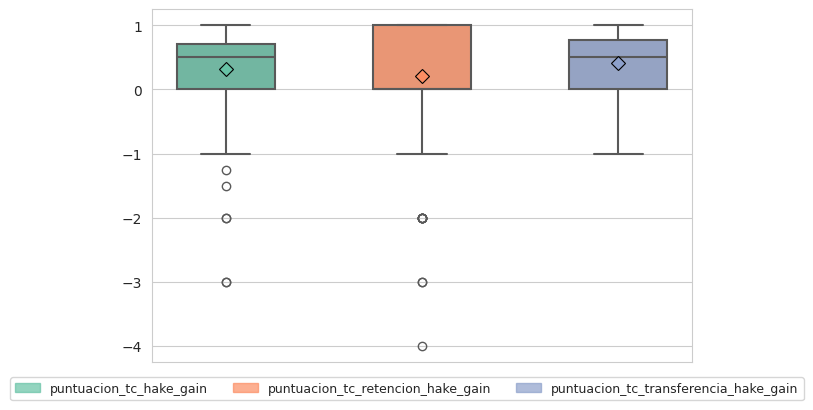

In [43]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        analysis_quant_cols
    ],
    showfliers=True,
    title=False,
    labelbottom=False
)

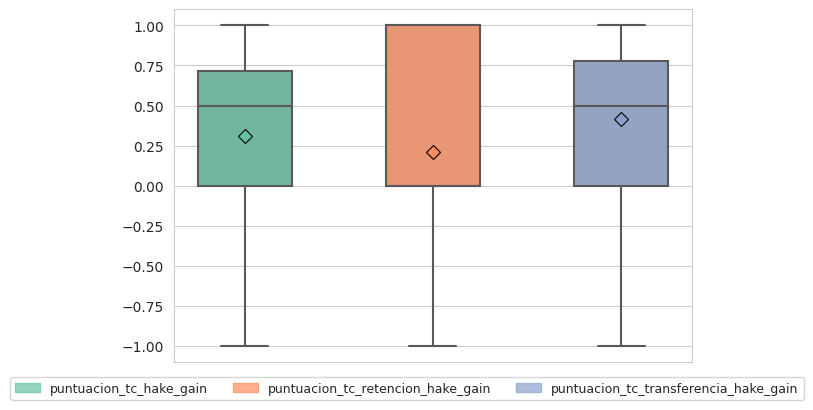

In [44]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        analysis_quant_cols
    ],
    showfliers=False,
    title=False,
    labelbottom=False
)

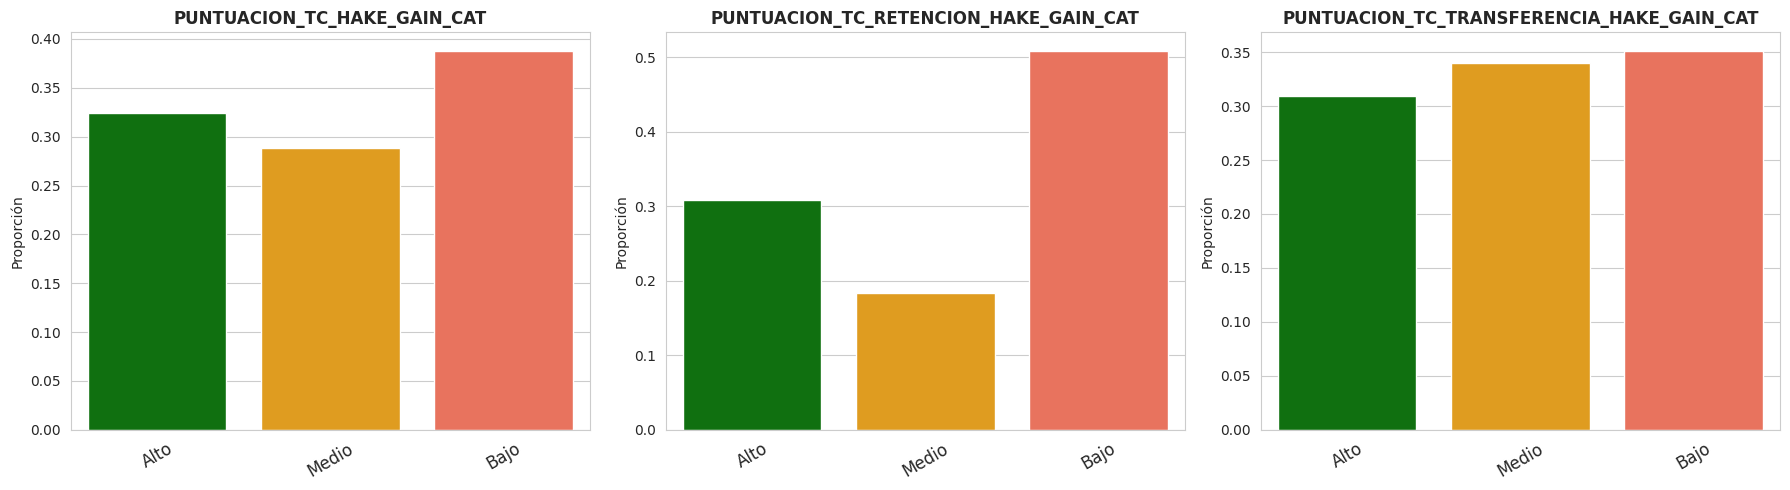

In [45]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = analysis_cat_cols, 
    order=['Alto', 'Medio', 'Bajo'],
    palette={'Alto': 'green', 'Medio': 'orange', 'Bajo': 'tomato'},
    max_cols=3
)

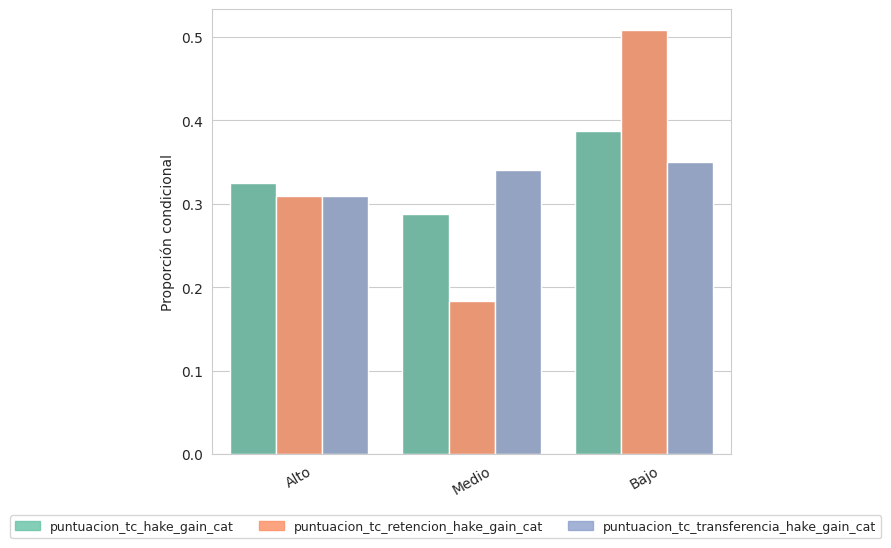

In [46]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        analysis_cat_cols
    ], 
    title=False,
    bbox_to_anchor=(0.5,-0.1),
    order=['Alto', 'Medio', 'Bajo']
)


#### TC-Hake por Grupos (Control vs Experimental)

In [54]:
for col in analysis_quant_cols:

    print("="*150)
    print(col.upper())
    print("="*150)
    
    display(
        group_stats(
            df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_experimental_ids)), 
            cols =  [col], 
            group_by = 'grupo'
        ).sort('grupo')
    )

PUNTUACION_TC_HAKE_GAIN


grupo,puntuacion_tc_hake_gain_mean,puntuacion_tc_hake_gain_std,puntuacion_tc_hake_gain_q25,puntuacion_tc_hake_gain_median,puntuacion_tc_hake_gain_q75,puntuacion_tc_hake_gain_min,puntuacion_tc_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""control""",0.405216,0.554484,0.167,0.5,0.75,-2.0,1.0
"""experimental""",0.248714,0.675574,0.0,0.4,0.6,-3.0,1.0


PUNTUACION_TC_RETENCION_HAKE_GAIN


grupo,puntuacion_tc_retencion_hake_gain_mean,puntuacion_tc_retencion_hake_gain_std,puntuacion_tc_retencion_hake_gain_q25,puntuacion_tc_retencion_hake_gain_median,puntuacion_tc_retencion_hake_gain_q75,puntuacion_tc_retencion_hake_gain_min,puntuacion_tc_retencion_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""control""",0.301577,0.80297,0.0,0.5,1.0,-4.0,1.0
"""experimental""",0.162099,0.811226,0.0,0.0,1.0,-3.0,1.0


PUNTUACION_TC_TRANSFERENCIA_HAKE_GAIN


grupo,puntuacion_tc_transferencia_hake_gain_mean,puntuacion_tc_transferencia_hake_gain_std,puntuacion_tc_transferencia_hake_gain_q25,puntuacion_tc_transferencia_hake_gain_median,puntuacion_tc_transferencia_hake_gain_q75,puntuacion_tc_transferencia_hake_gain_min,puntuacion_tc_transferencia_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""control""",0.481639,0.481089,0.0,0.5,1.0,-1.0,1.0
"""experimental""",0.365747,0.523519,0.0,0.5,0.75,-1.0,1.0


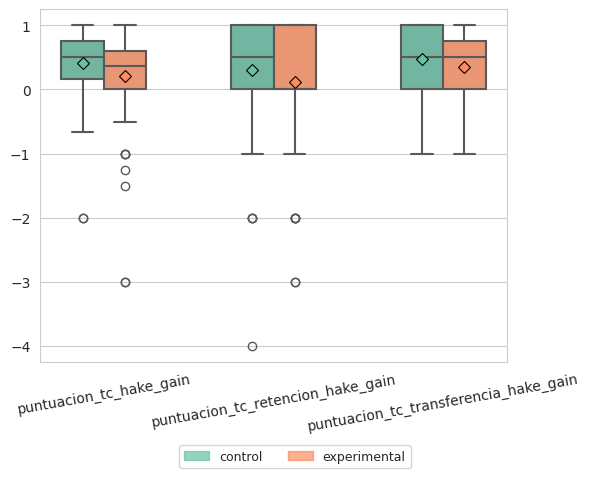

In [48]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        analysis_quant_cols
    ],
    group_by='grupo',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

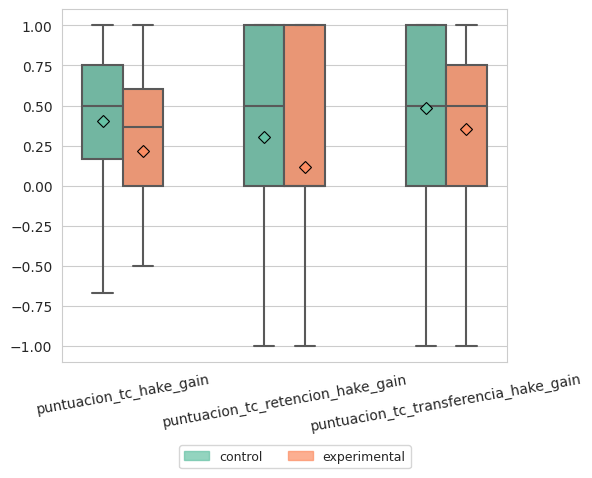

In [49]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        analysis_quant_cols
    ],
    group_by='grupo',
    showfliers=False,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

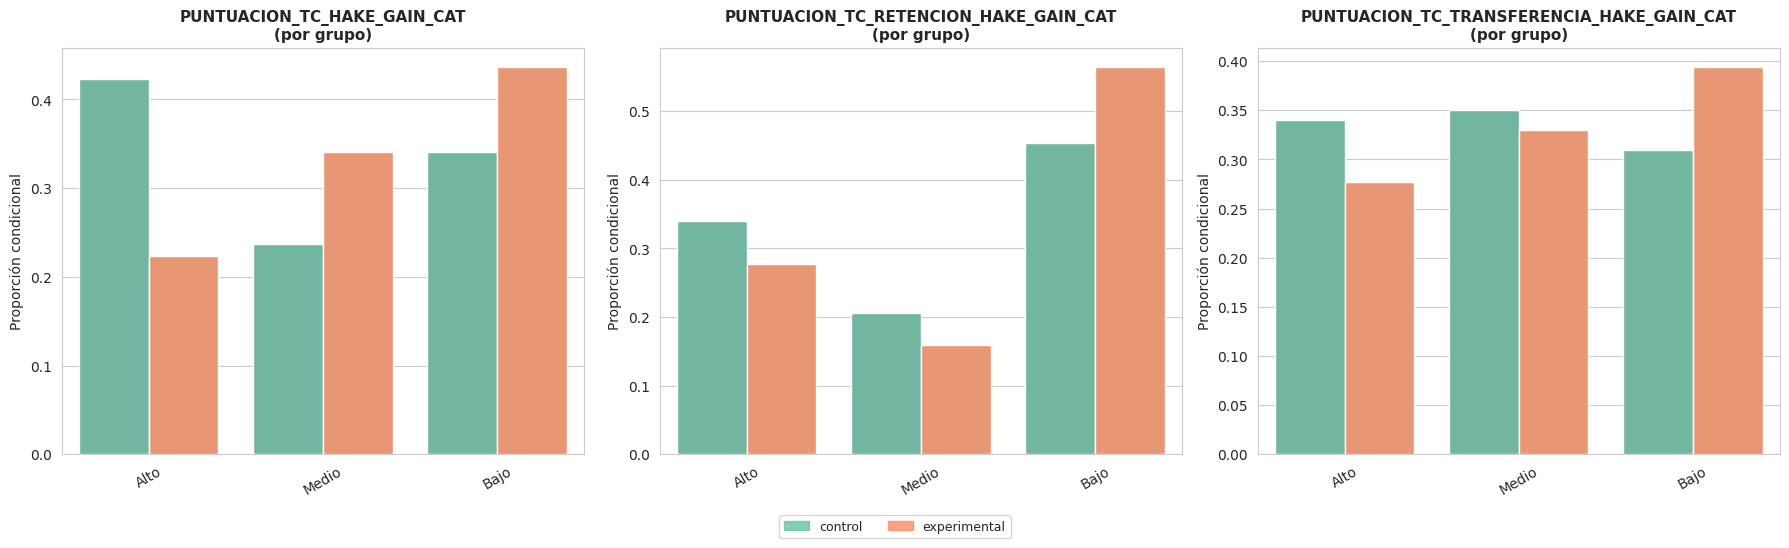

In [50]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['puntuacion_tc_hake_gain_cat'],
        ['puntuacion_tc_retencion_hake_gain_cat'],
        ['puntuacion_tc_transferencia_hake_gain_cat']
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.1),
    order=['Alto', 'Medio', 'Bajo'],
    group_by='grupo',
)


#### TC-Hake por Grupos Avanzado (Control vs Tipos de Experimentales)

In [53]:
for col in analysis_quant_cols:

    print("="*150)
    print(col.upper())
    print("="*150)
    
    display(
        group_stats(
            df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_experimental_ids)), 
            cols =  [col], 
            group_by = 'grupo_segmented'
        ).sort('grupo_segmented')
    )

PUNTUACION_TC_HAKE_GAIN


grupo_segmented,puntuacion_tc_hake_gain_mean,puntuacion_tc_hake_gain_std,puntuacion_tc_hake_gain_q25,puntuacion_tc_hake_gain_median,puntuacion_tc_hake_gain_q75,puntuacion_tc_hake_gain_min,puntuacion_tc_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""AA""",0.388833,0.779325,0.0,0.833,1.0,-1.0,1.0
"""AB""",0.023478,1.059468,0.0,0.4,0.6,-3.0,1.0
"""BA""",0.3875,0.291455,0.25,0.5,0.5,0.0,0.833
"""BB""",0.3022,0.468425,0.0,0.333,0.6,-1.5,1.0
"""control""",0.405216,0.554484,0.167,0.5,0.75,-2.0,1.0


PUNTUACION_TC_RETENCION_HAKE_GAIN


grupo_segmented,puntuacion_tc_retencion_hake_gain_mean,puntuacion_tc_retencion_hake_gain_std,puntuacion_tc_retencion_hake_gain_q25,puntuacion_tc_retencion_hake_gain_median,puntuacion_tc_retencion_hake_gain_q75,puntuacion_tc_retencion_hake_gain_min,puntuacion_tc_retencion_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""AA""",0.111167,1.572943,0.0,1.0,1.0,-3.0,1.0
"""AB""",0.079696,0.789557,0.0,0.0,0.5,-2.0,1.0
"""BA""",0.388917,0.648762,0.0,0.667,1.0,-1.0,1.0
"""BB""",0.15168,0.752112,0.0,0.0,0.75,-2.0,1.0
"""control""",0.301577,0.80297,0.0,0.5,1.0,-4.0,1.0


PUNTUACION_TC_TRANSFERENCIA_HAKE_GAIN


grupo_segmented,puntuacion_tc_transferencia_hake_gain_mean,puntuacion_tc_transferencia_hake_gain_std,puntuacion_tc_transferencia_hake_gain_q25,puntuacion_tc_transferencia_hake_gain_median,puntuacion_tc_transferencia_hake_gain_q75,puntuacion_tc_transferencia_hake_gain_min,puntuacion_tc_transferencia_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""AA""",0.361167,0.561826,0.0,0.5,1.0,-0.333,1.0
"""AB""",0.280391,0.666262,0.0,0.5,0.75,-1.0,1.0
"""BA""",0.354167,0.289018,0.0,0.5,0.5,0.0,0.75
"""BB""",0.40834,0.49782,0.0,0.5,0.75,-1.0,1.0
"""control""",0.481639,0.481089,0.0,0.5,1.0,-1.0,1.0


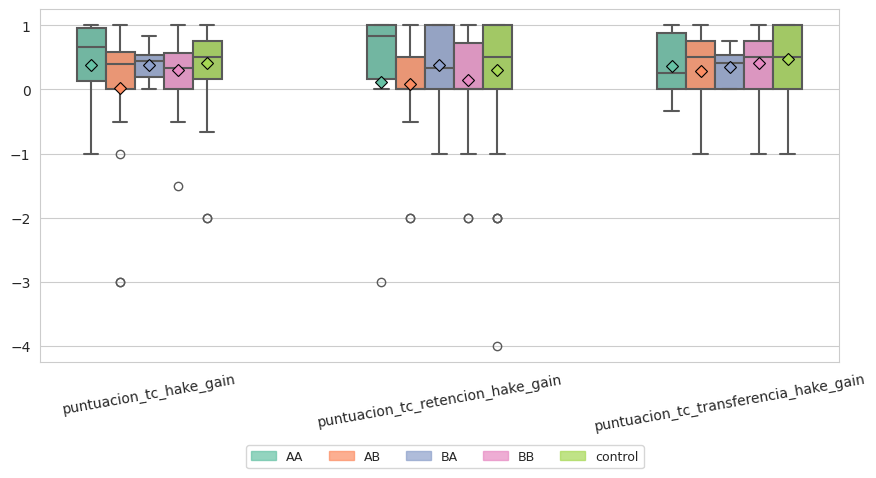

In [ ]:
plot_quant_comparison(
    figsize = (9,4),
    df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_experimental_ids)),
    comparisons = [
        analysis_quant_cols
    ],
    group_by='grupo_segmented',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

PUNTUACION_TCC_INT_CAT_POST

── CONDICIÓN: BAJO - n = 62 ──


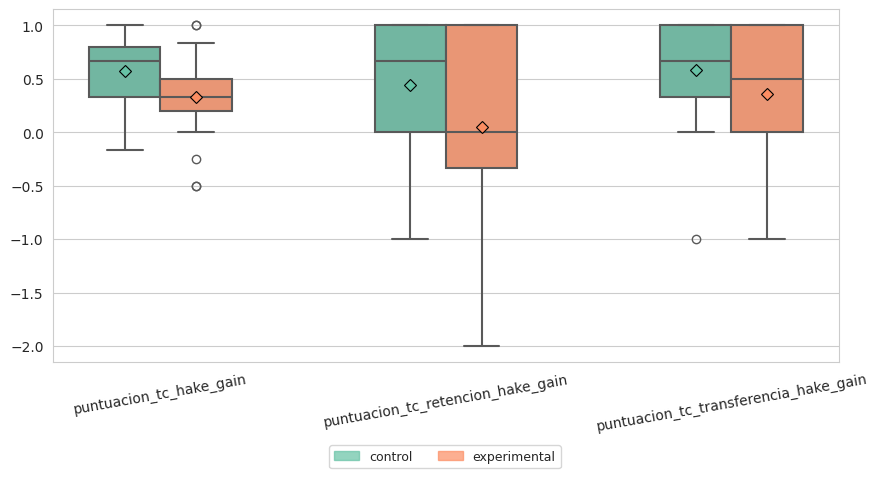

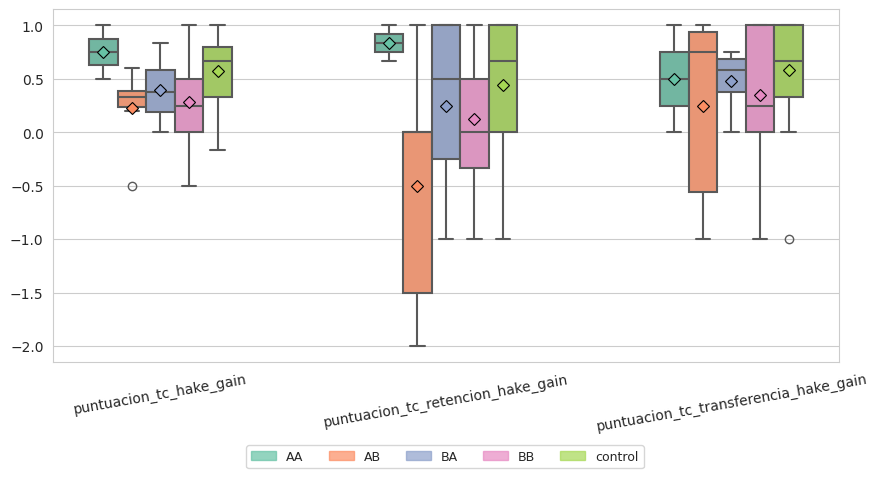


── CONDICIÓN: MEDIO - n = 67 ──


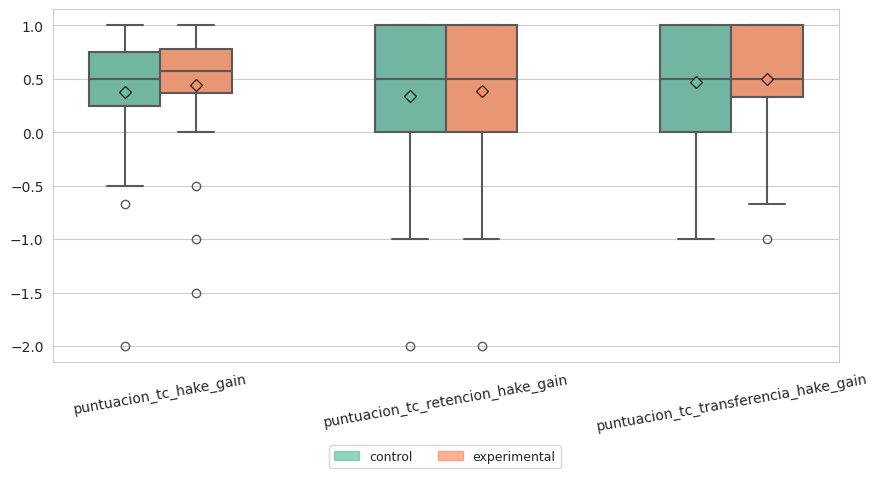

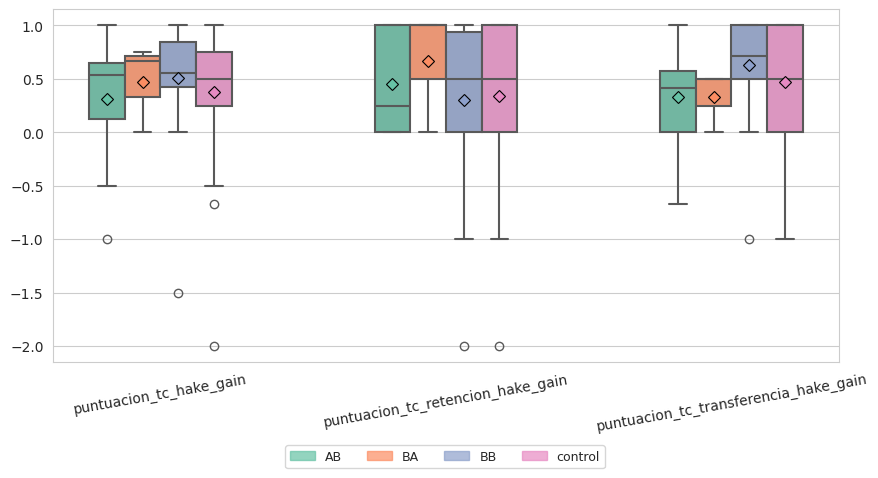


── CONDICIÓN: ALTO - n = 59 ──


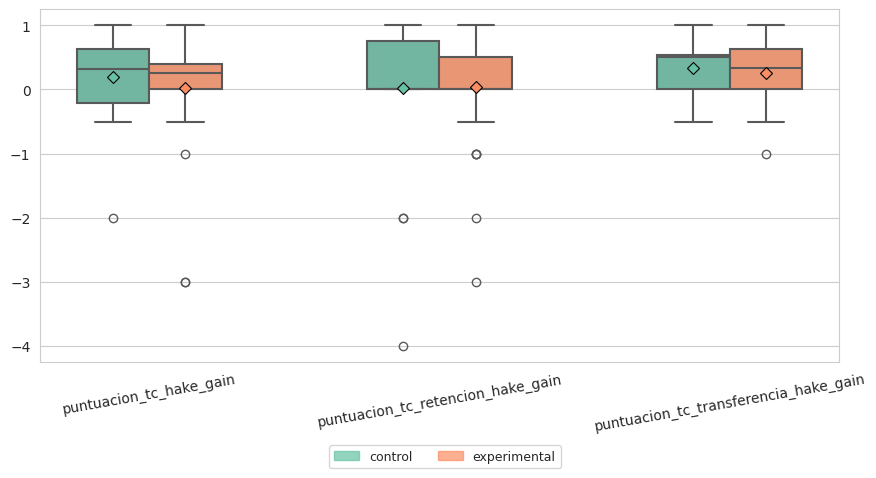

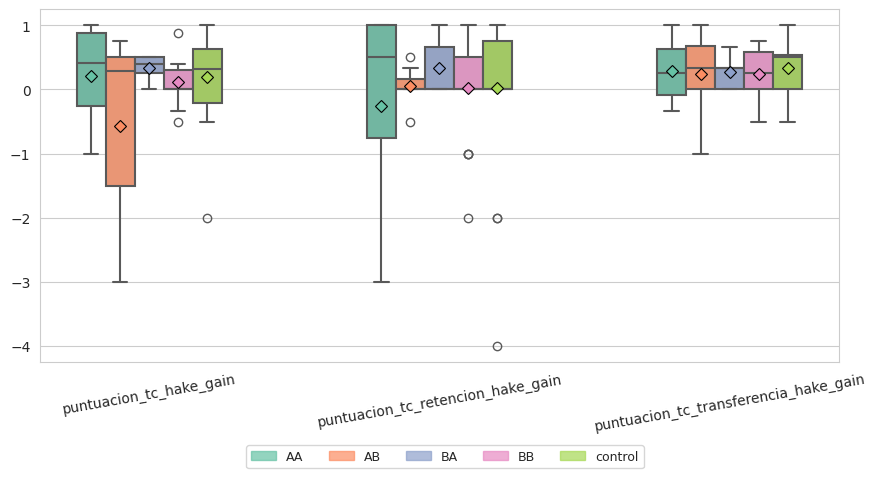

PUNTUACION_TCC_EXT_CAT_POST

── CONDICIÓN: BAJO - n = 69 ──


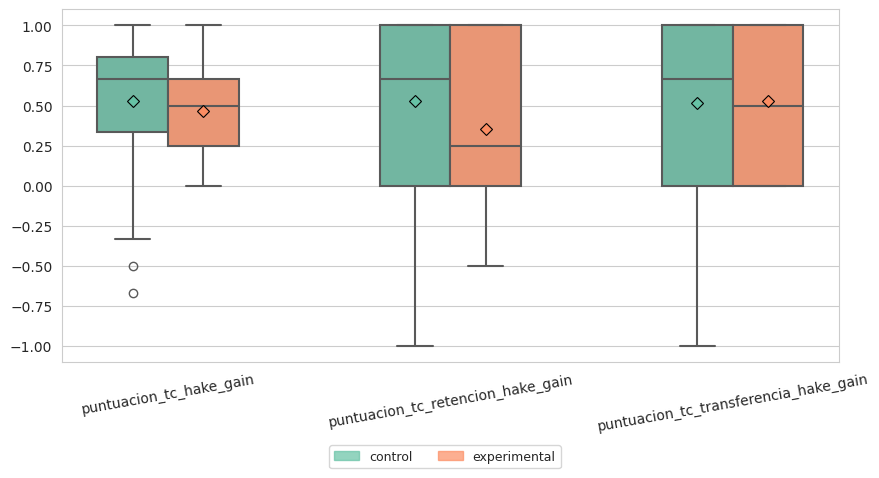

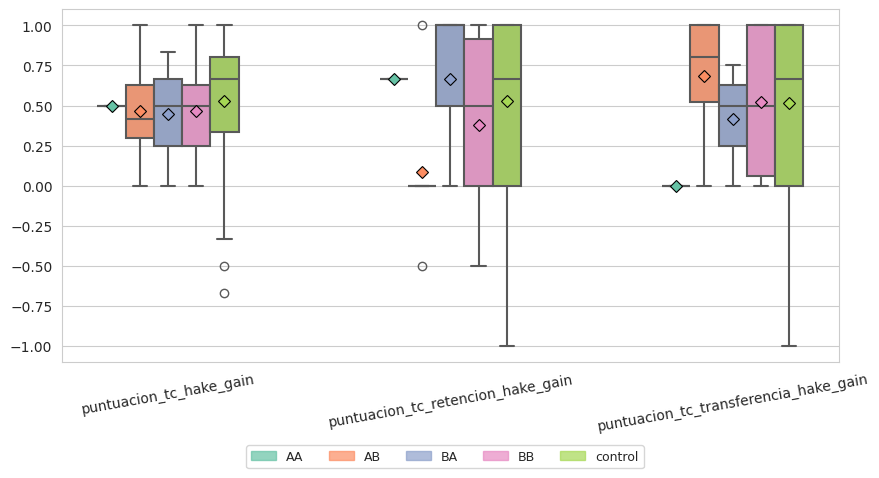


── CONDICIÓN: MEDIO - n = 68 ──


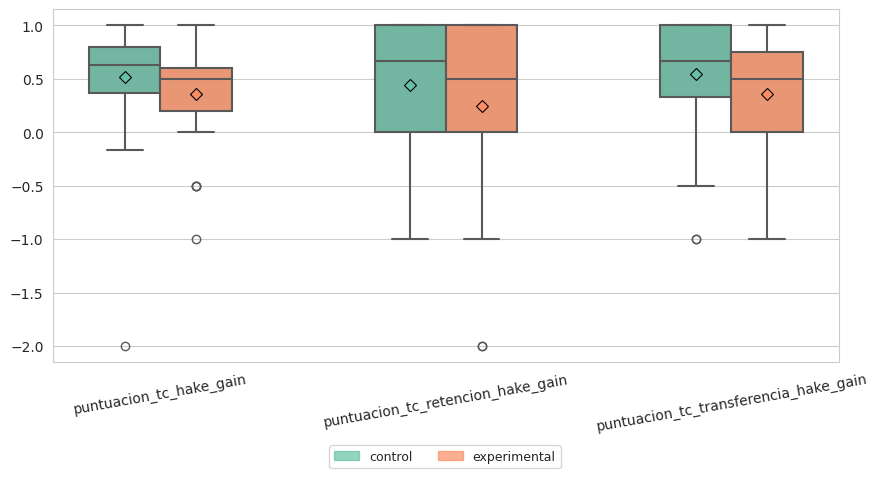

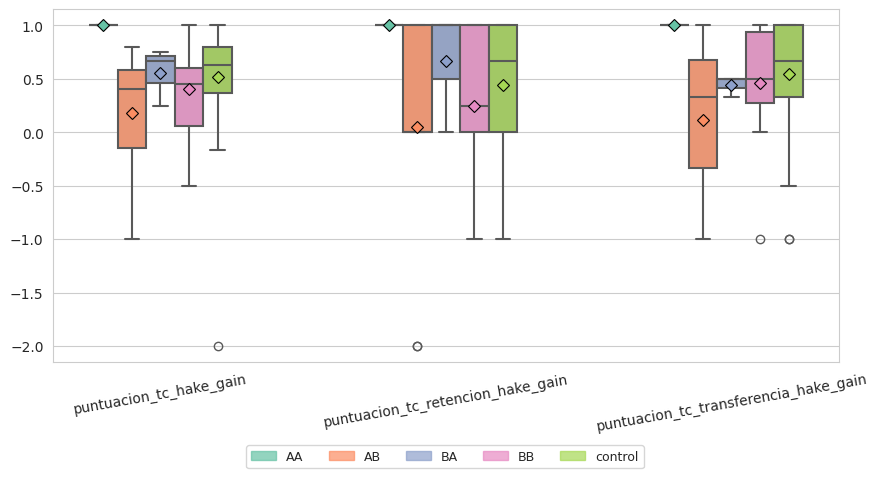


── CONDICIÓN: ALTO - n = 51 ──


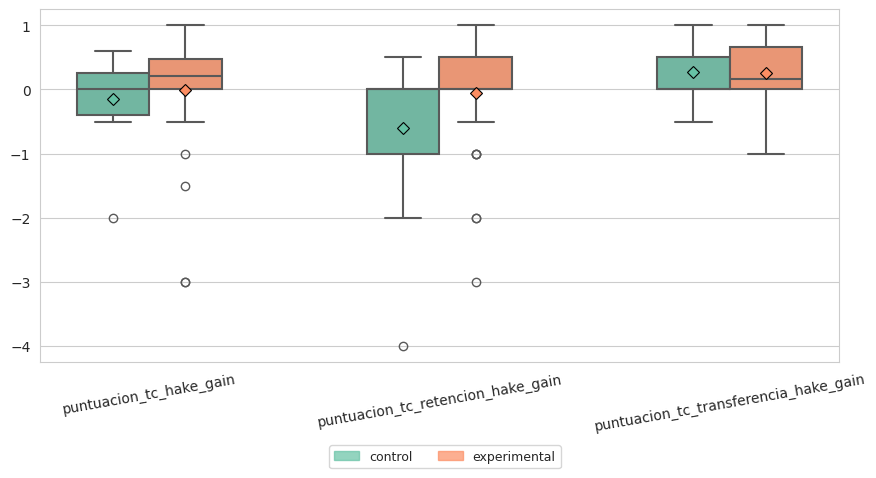

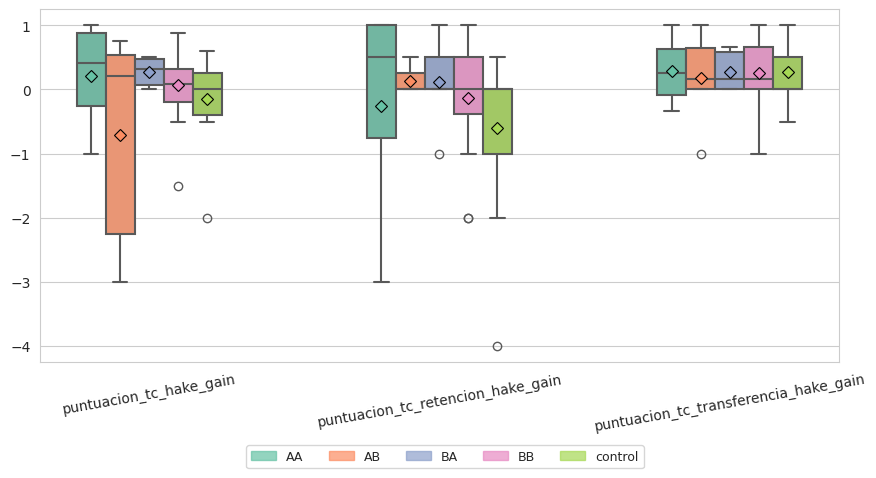

PUNTUACION_TCC_REL_CAT_POST

── CONDICIÓN: BAJO - n = 70 ──


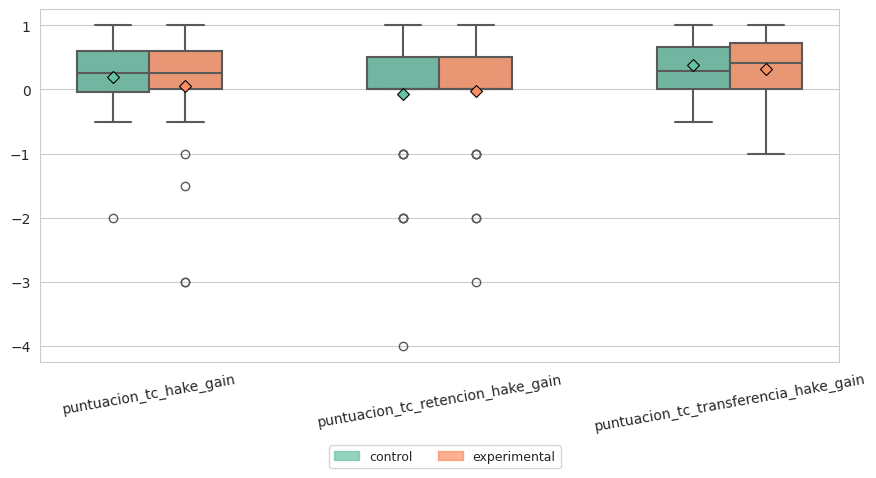

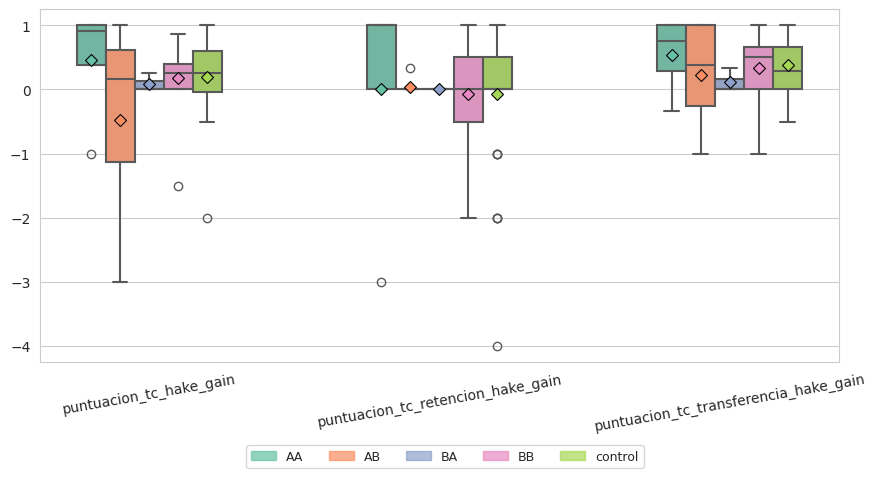


── CONDICIÓN: MEDIO - n = 64 ──


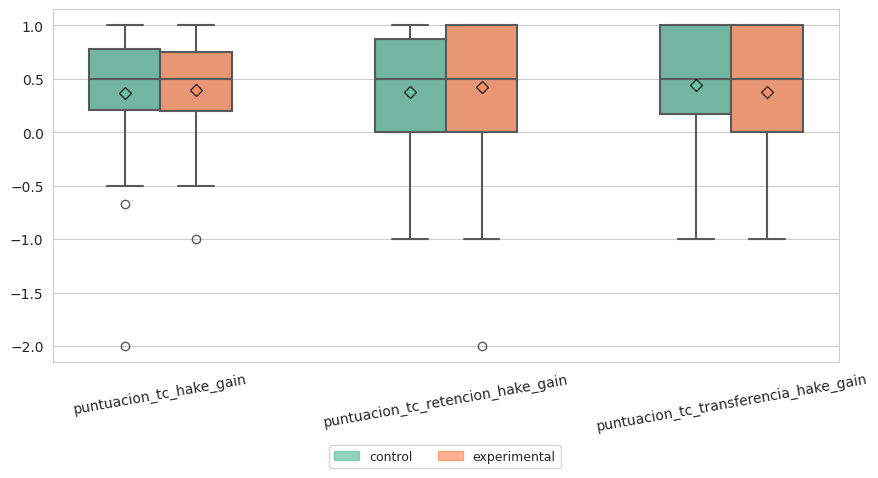

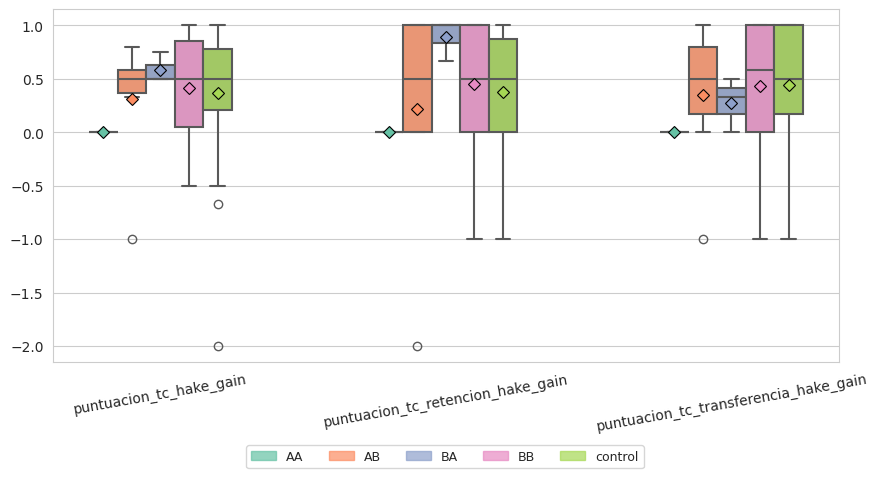


── CONDICIÓN: ALTO - n = 54 ──


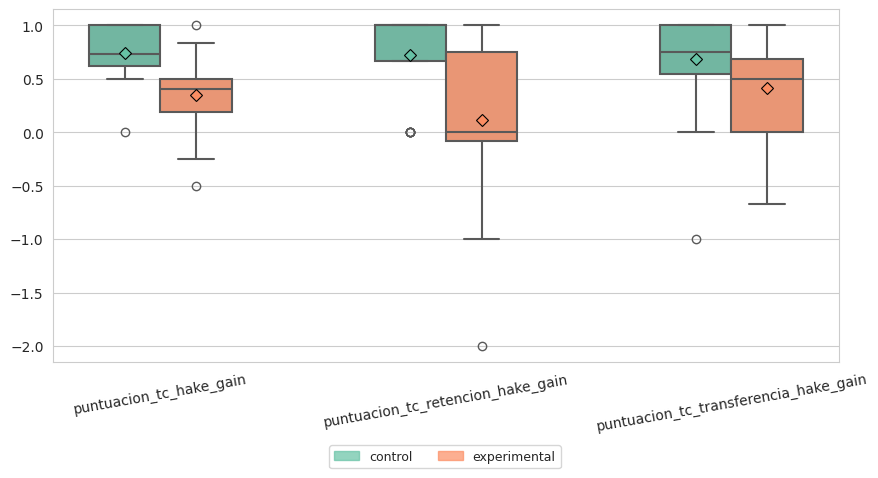

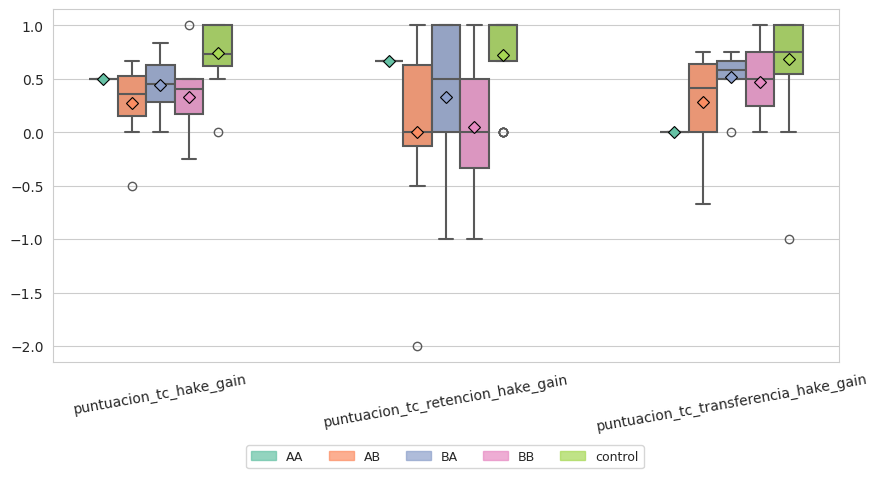

PUNTUACION_TA_CAT_PRE

── CONDICIÓN: BAJO - n = 76 ──


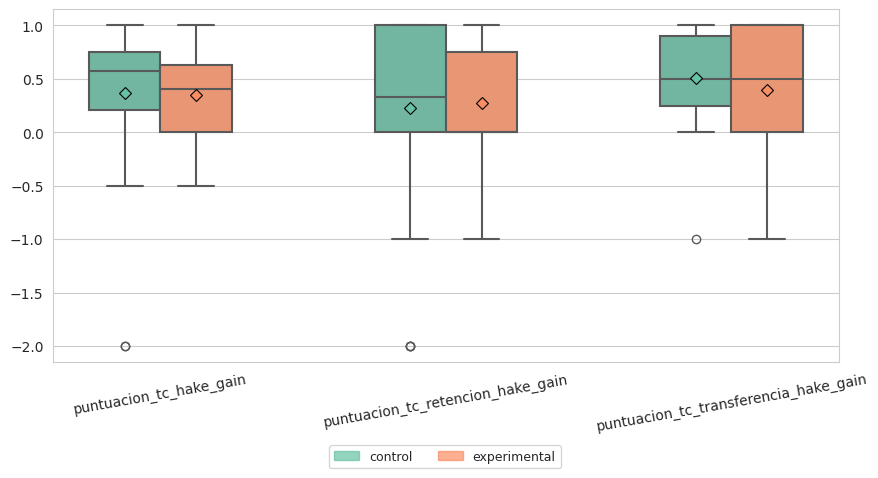

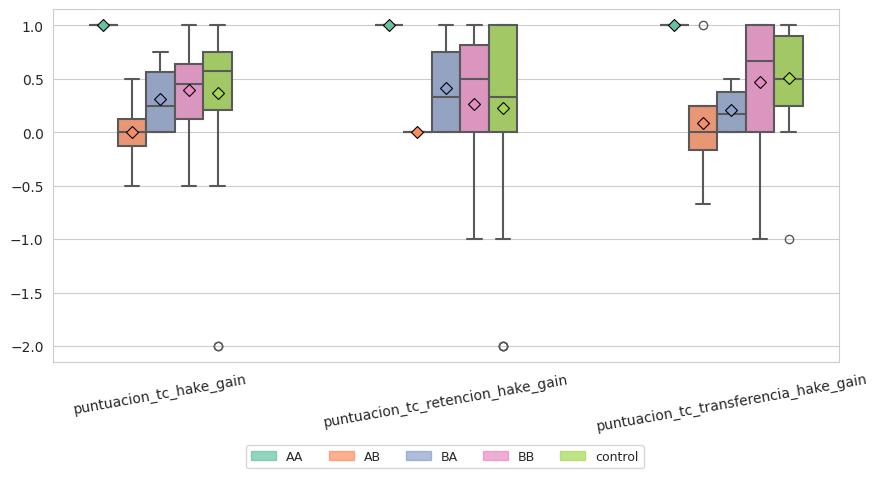


── CONDICIÓN: MEDIO - n = 54 ──


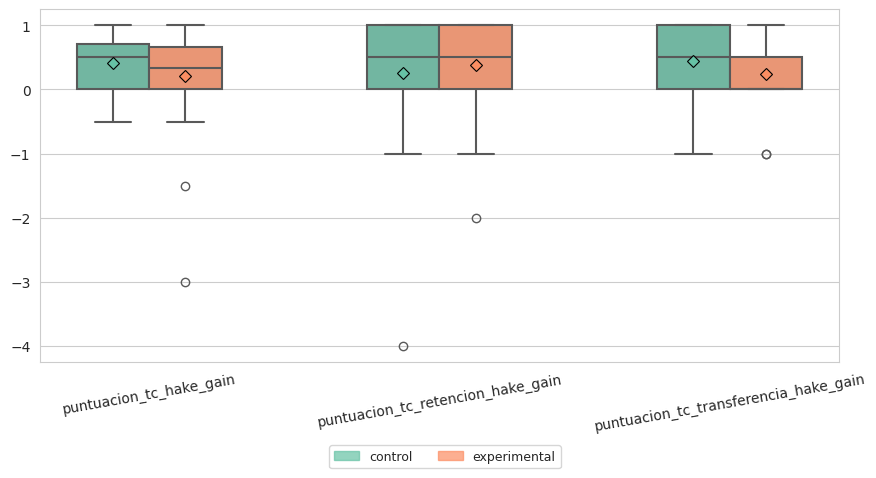

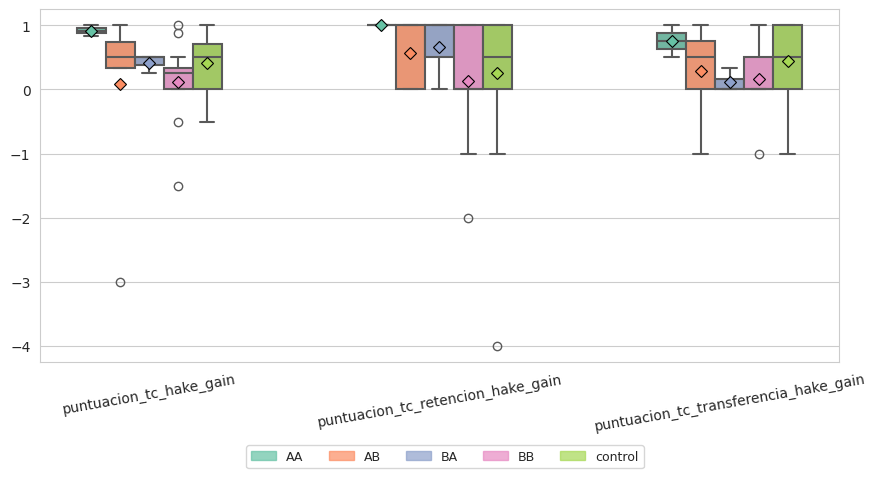


── CONDICIÓN: ALTO - n = 58 ──


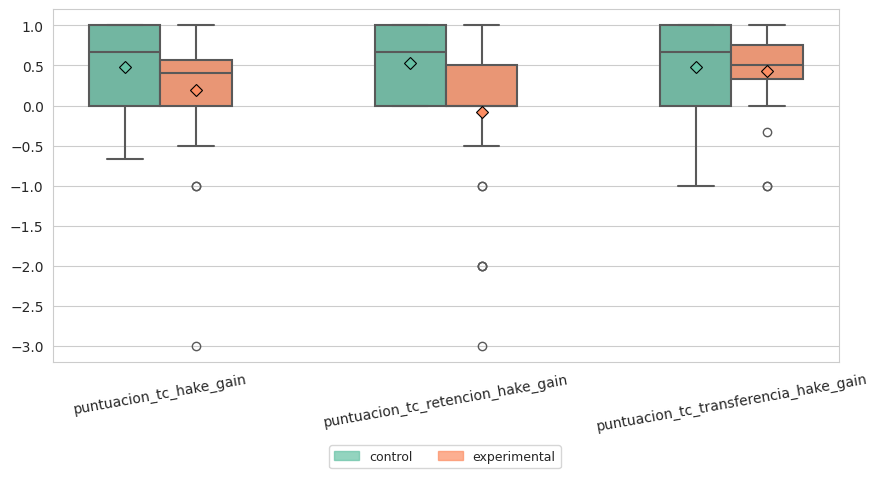

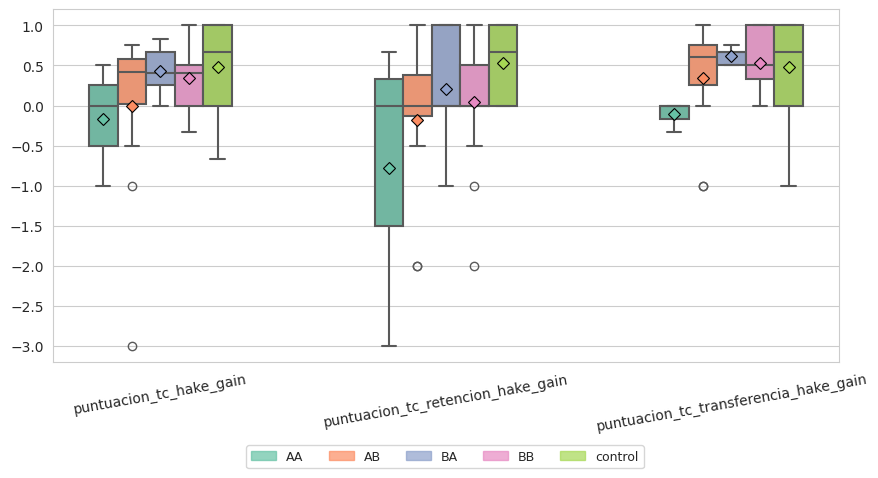

PUNTUACION_TA_CAT_POST

── CONDICIÓN: BAJO - n = 67 ──


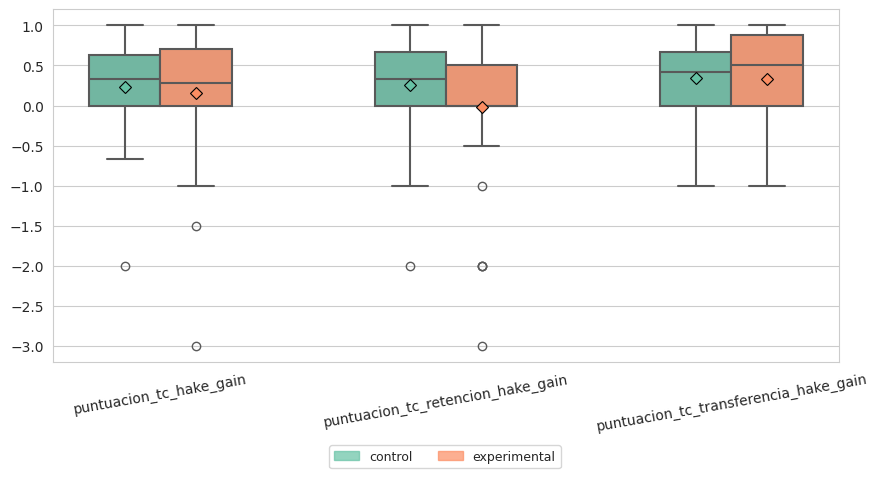

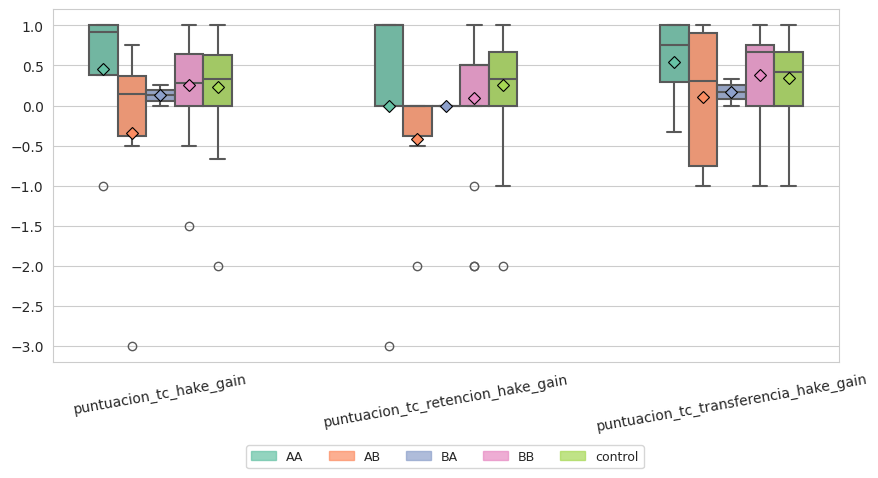


── CONDICIÓN: MEDIO - n = 60 ──


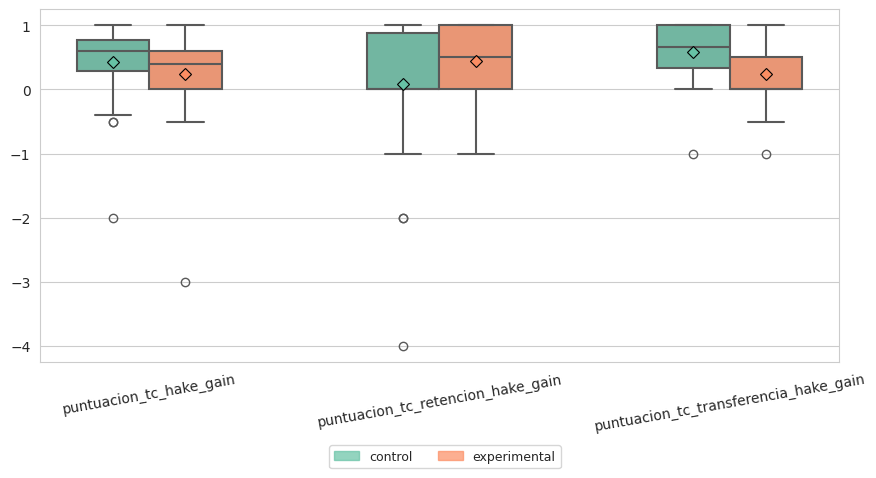

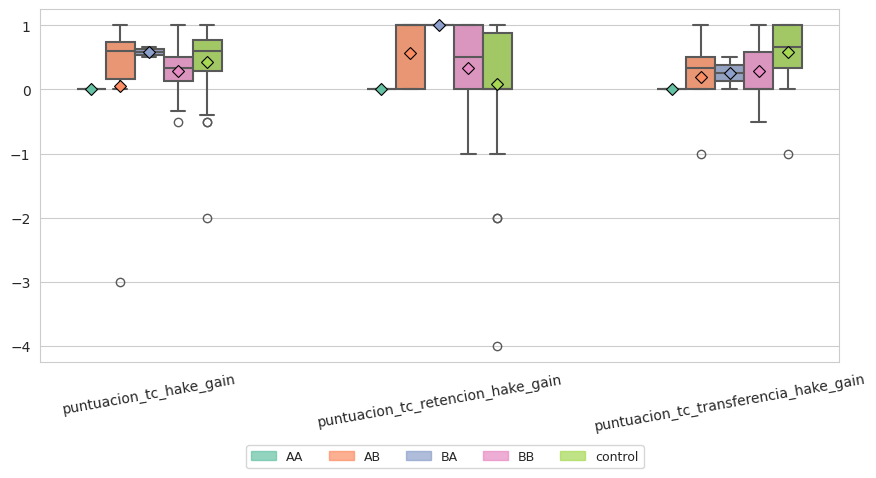


── CONDICIÓN: ALTO - n = 61 ──


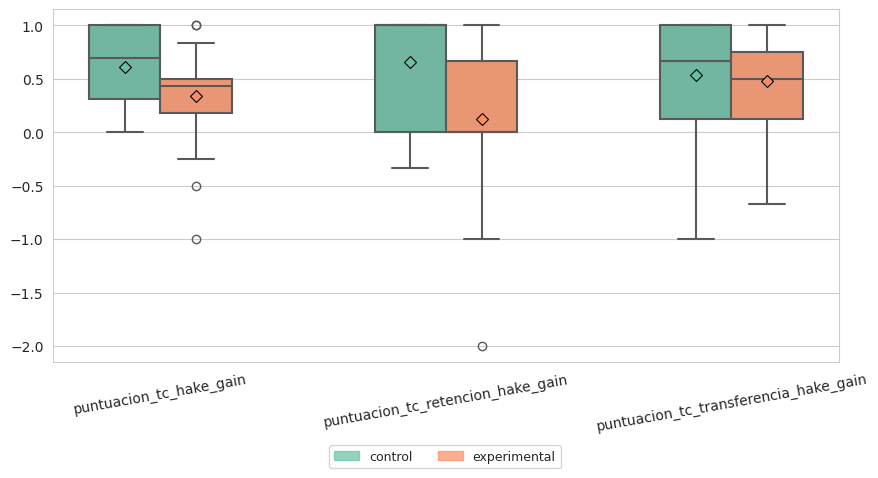

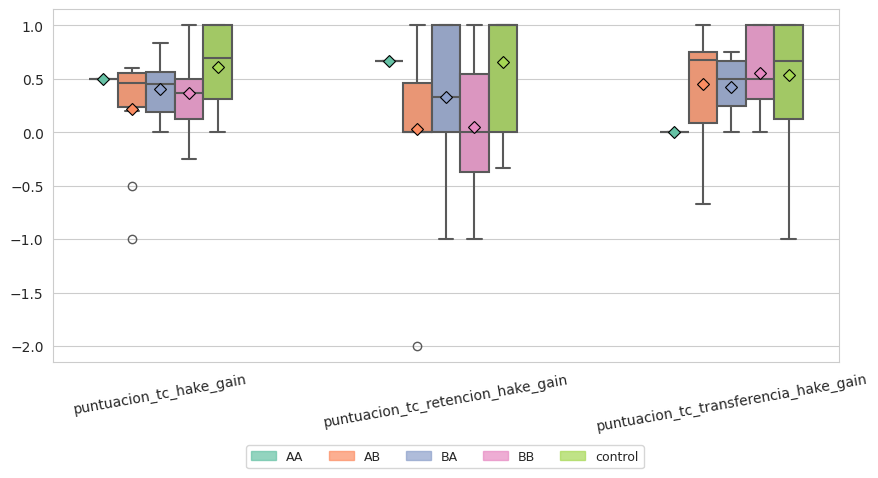

PUNTUACION_TC_CAT_PRE

── CONDICIÓN: BAJO - n = 63 ──


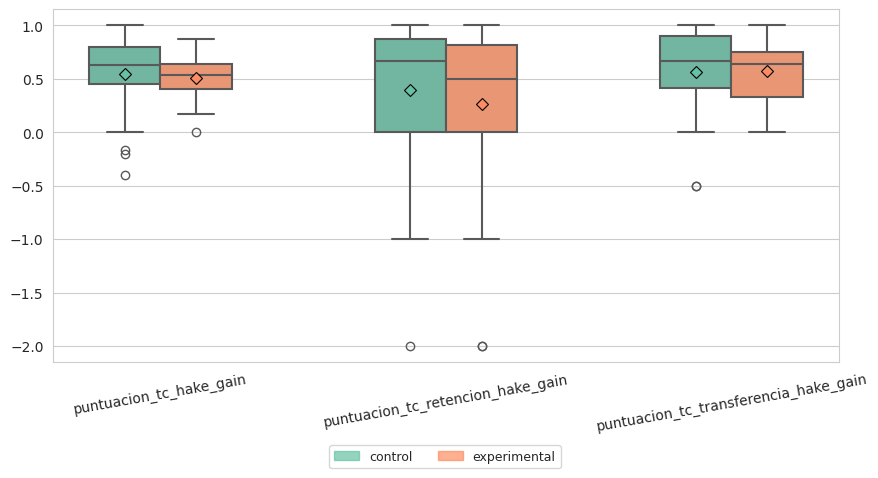

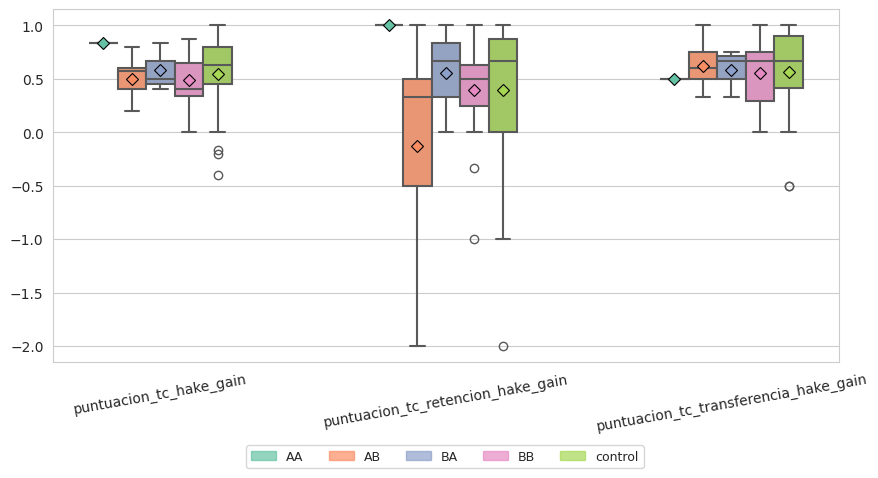


── CONDICIÓN: MEDIO - n = 82 ──


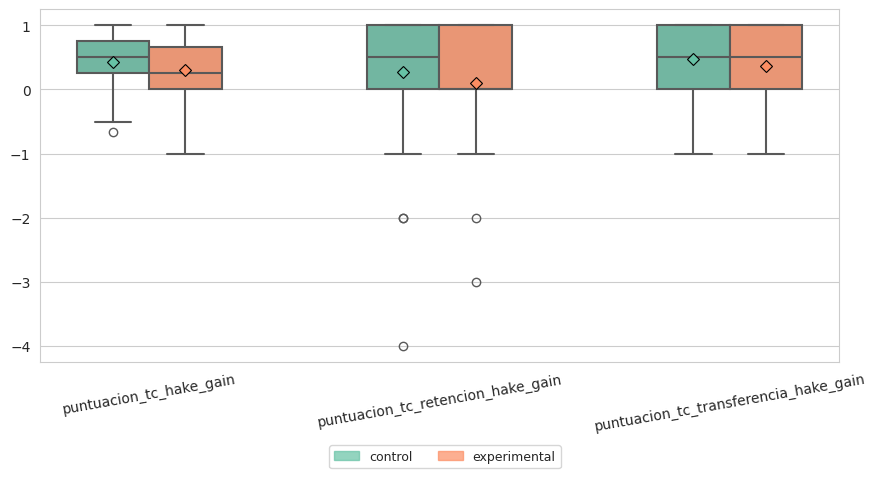

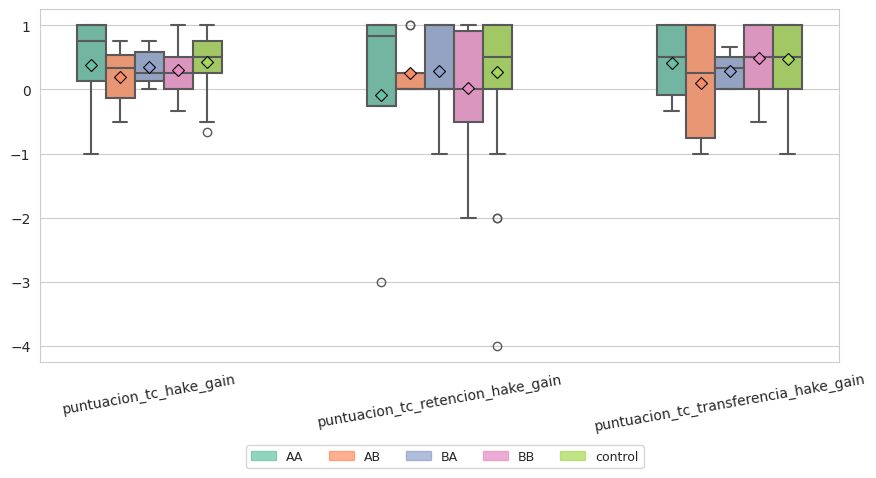


── CONDICIÓN: ALTO - n = 43 ──


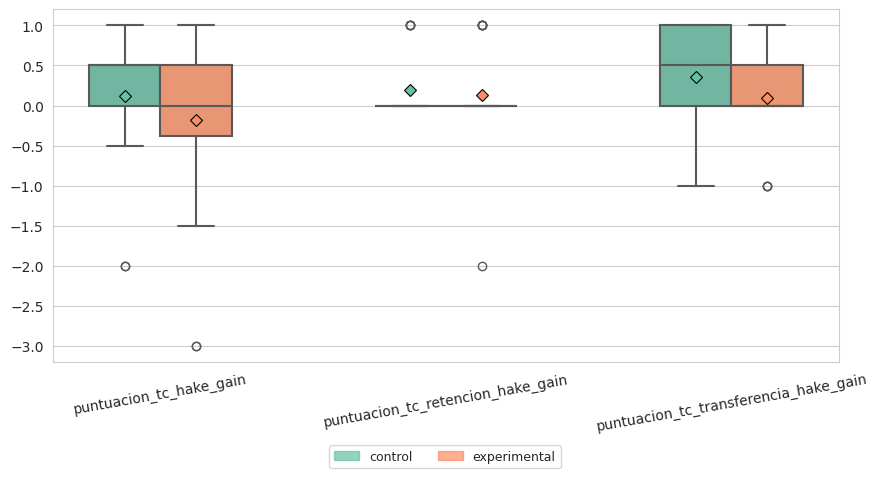

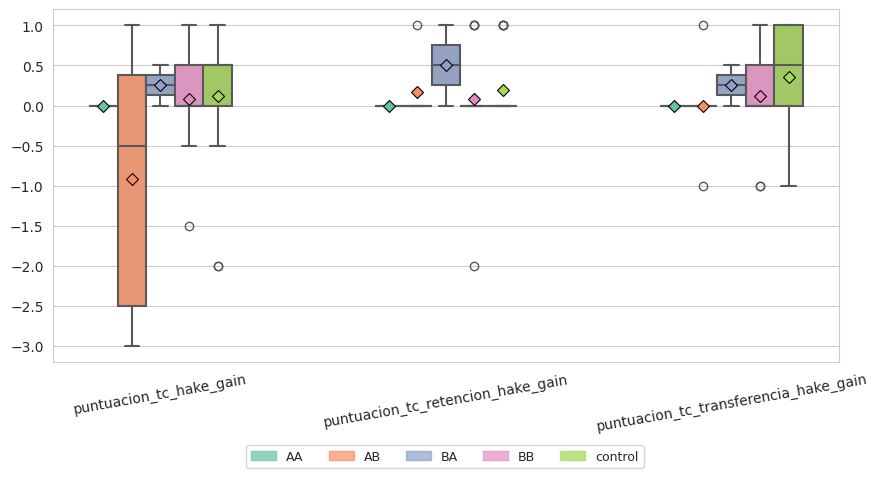

PUNTUACION_TC_CAT_POST

── CONDICIÓN: BAJO - n = 79 ──


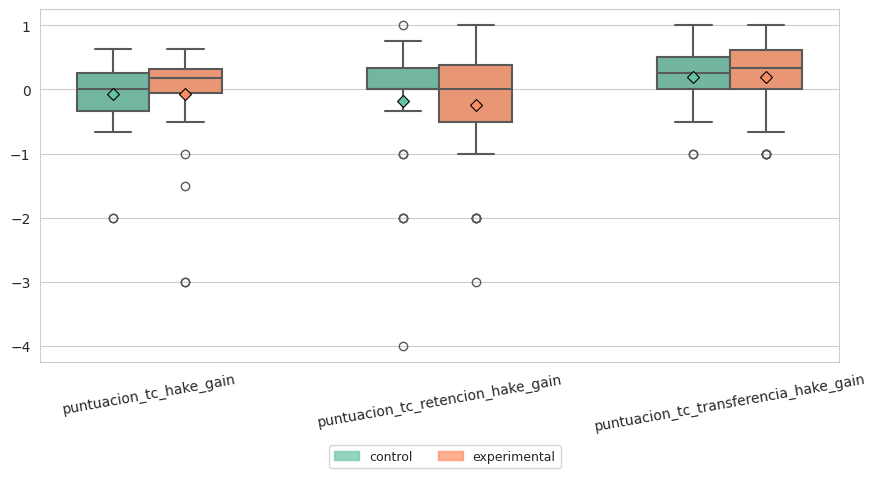

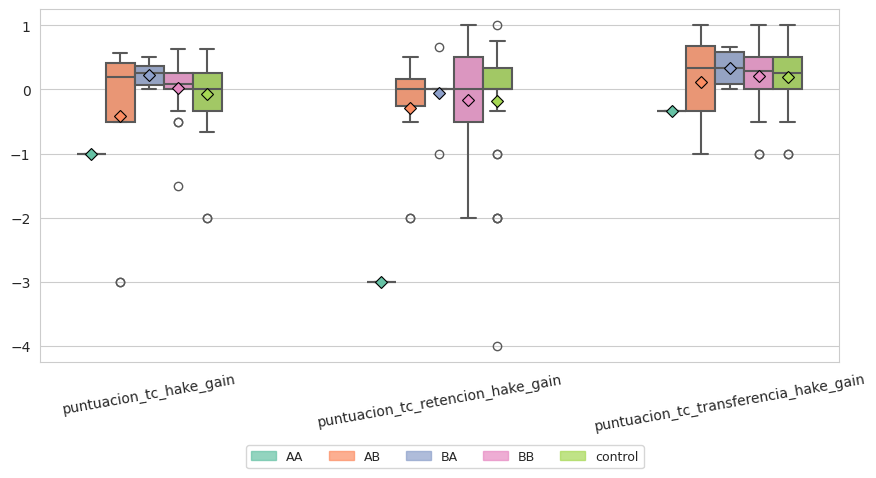


── CONDICIÓN: MEDIO - n = 84 ──


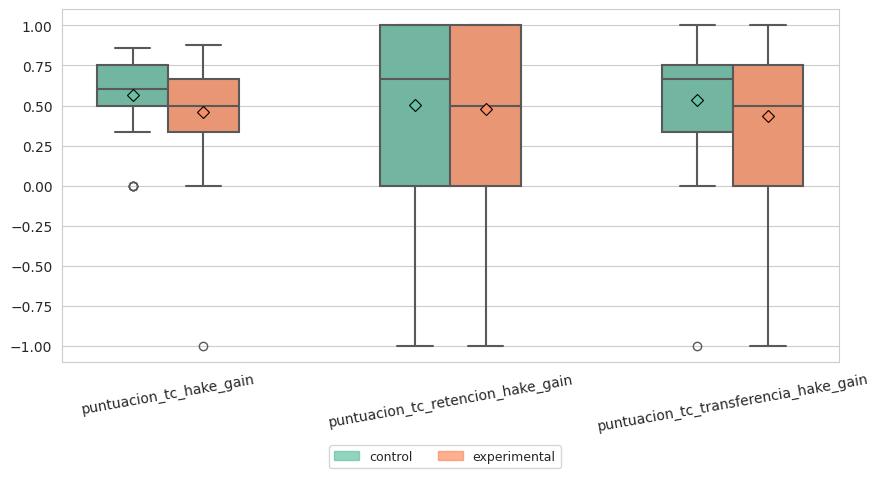

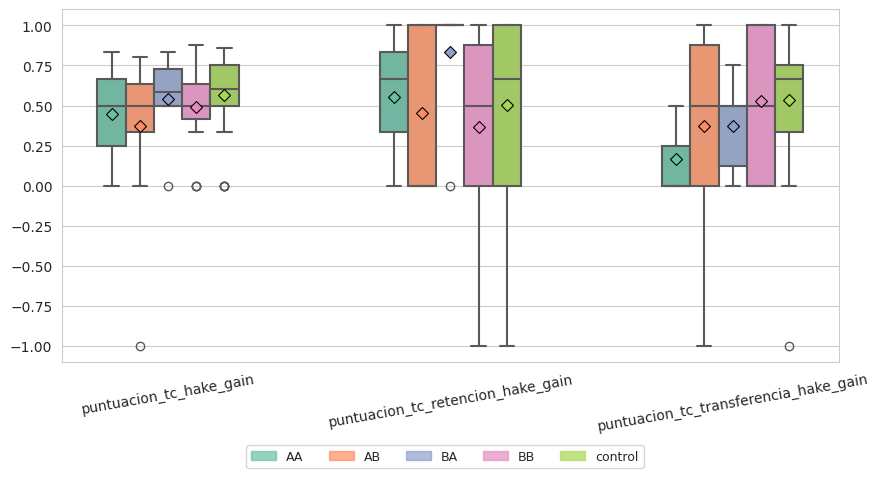


── CONDICIÓN: ALTO - n = 25 ──


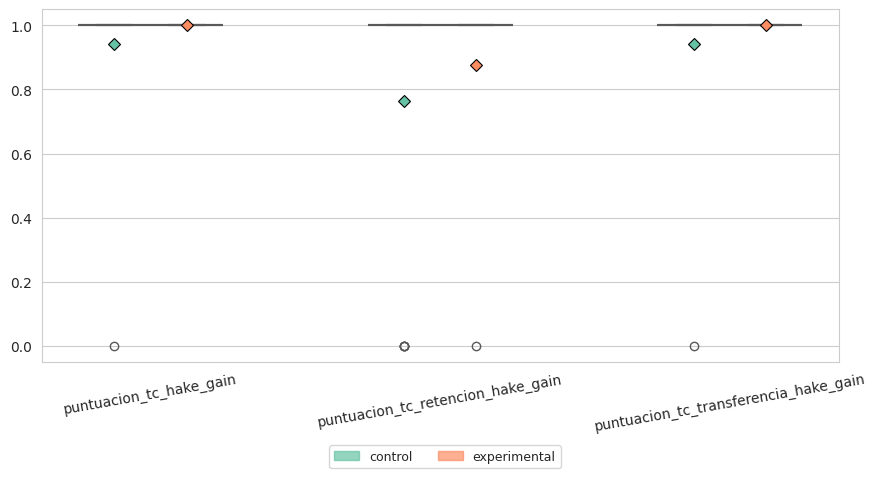

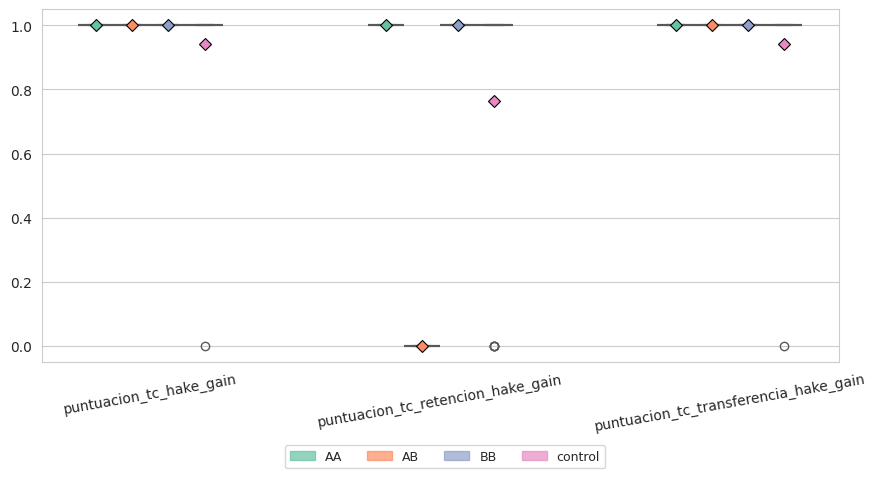

In [55]:
group_by_cols = [
    "puntuacion_tcc_int_cat_post",
    "puntuacion_tcc_ext_cat_post",
    "puntuacion_tcc_rel_cat_post", 
    "puntuacion_ta_cat_pre",
    "puntuacion_ta_cat_post",
    "puntuacion_tc_cat_pre",
    "puntuacion_tc_cat_post"
]
col_vals = ["Bajo", "Medio", "Alto"]

for col in group_by_cols:

    print("="*140)
    print(col.upper())
    print("="*140)

    for value in col_vals:

        df_filtered = (
            forms_interactions_df
            .filter(~pl.col('id').is_in(problematic_experimental_ids))
            .filter(pl.col(col) == value)
        )
        print(f"\n── CONDICIÓN: {value.upper()} - n = {len(df_filtered)} ──")

        plot_quant_comparison(
            figsize=(9, 4),
            df=df_filtered,
            comparisons=[
                ["puntuacion_tc_hake_gain", "puntuacion_tc_retencion_hake_gain", "puntuacion_tc_transferencia_hake_gain"]
            ],
            group_by='grupo',
            showfliers=True,
            title=False,
            labelbottom=True,
            xlabel_rotation=10,
            bbox_to_anchor=(0.5, -0.2)
        )

        plot_quant_comparison(
            figsize=(9, 4),
            df=df_filtered,
            comparisons=[
                ["puntuacion_tc_hake_gain", "puntuacion_tc_retencion_hake_gain", "puntuacion_tc_transferencia_hake_gain"]
            ],
            group_by='grupo_segmented',
            showfliers=True,
            title=False,
            labelbottom=True,
            xlabel_rotation=10,
            bbox_to_anchor=(0.5, -0.2)
        )

---

#### TC-Pre

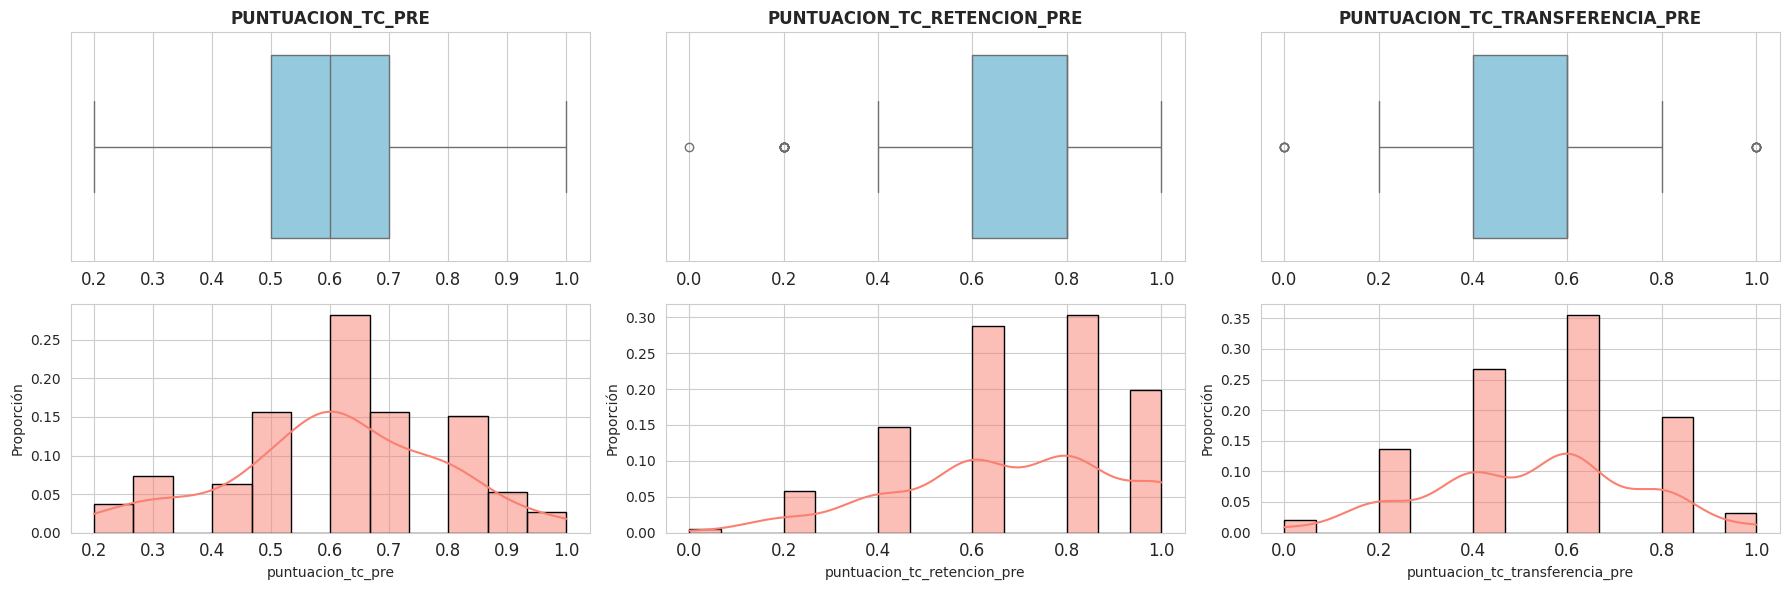

In [170]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = [col for col in forms_quant_cols if 'tc_' in col and 'hake' not in col and 'pre' in col], 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

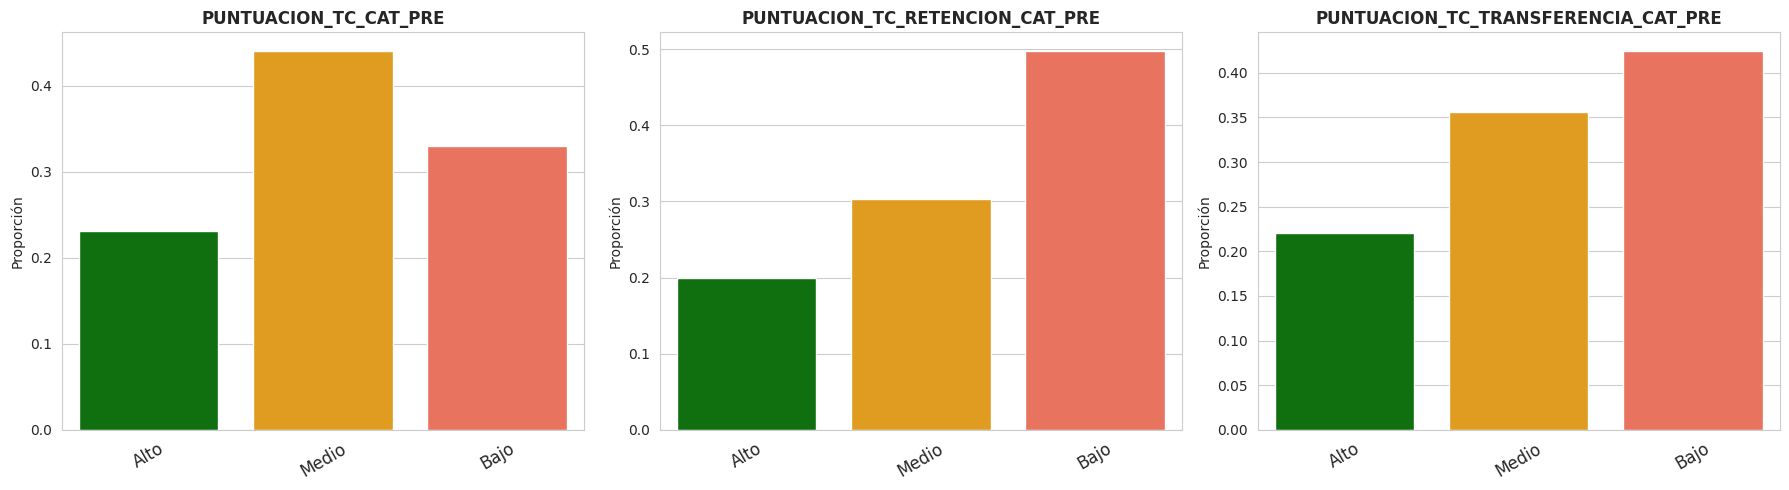

In [171]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = [col for col in forms_cat_cols if 'tc_' in col and 'hake' not in col and 'pre' in col], 
    max_cols=3, 
    order=['Alto', 'Medio', 'Bajo'],
    palette={'Alto': 'green', 'Medio': 'orange', 'Bajo': 'tomato'},
)

#### TC-Post

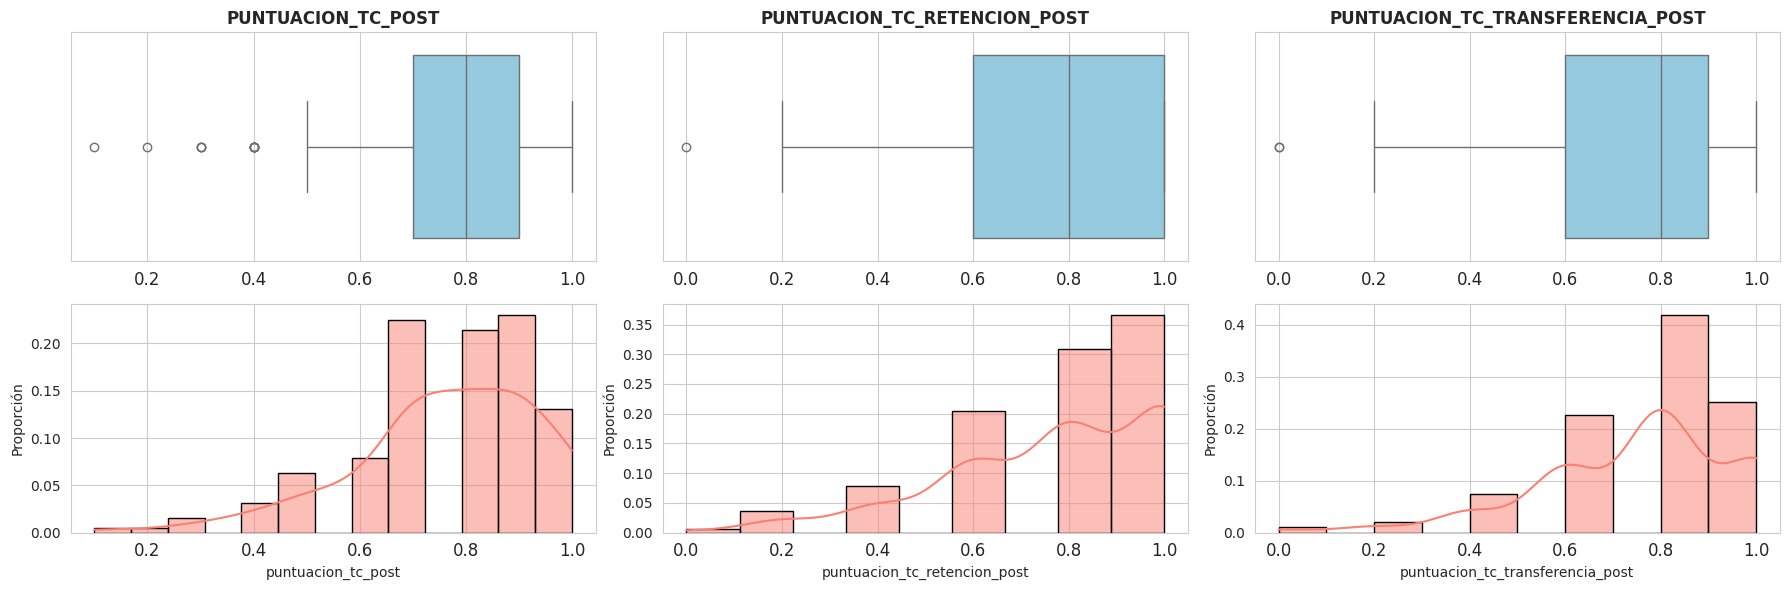

In [172]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = [col for col in forms_quant_cols if 'tc_' in col and 'hake' not in col and 'post' in col], 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

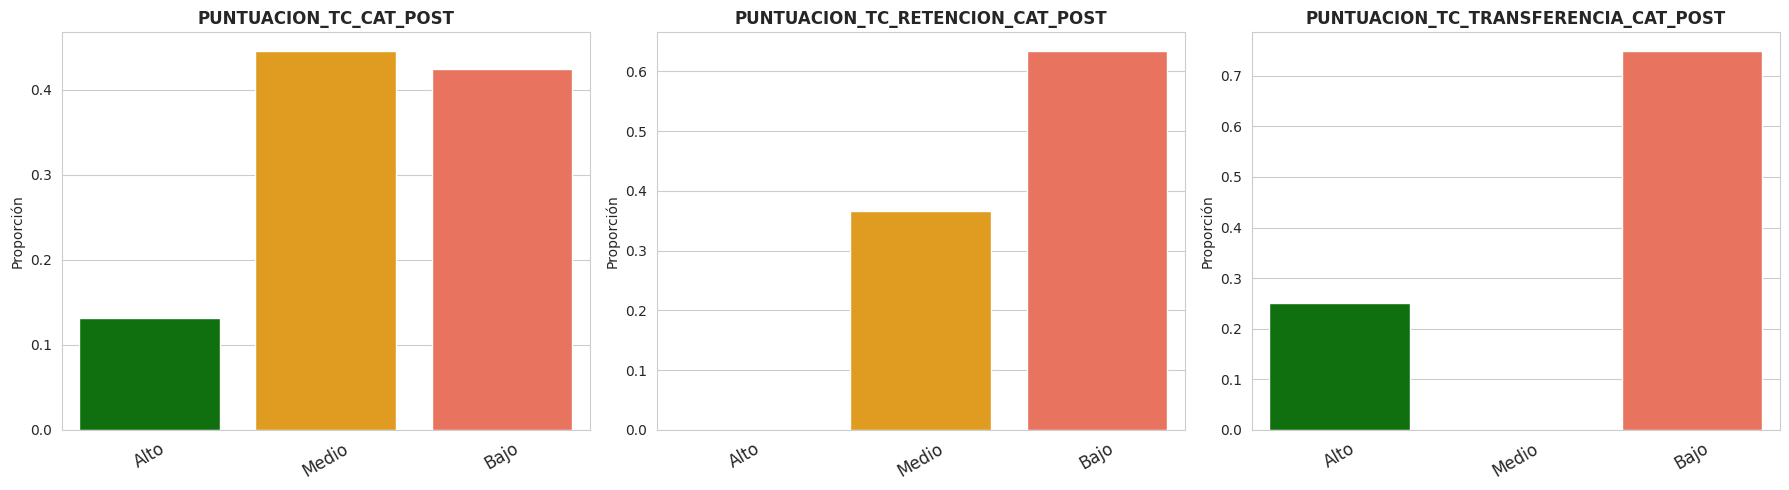

In [173]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = [col for col in forms_cat_cols if 'tc_' in col and 'hake' not in col and 'post' in col], 
    max_cols=3, 
    order=['Alto', 'Medio', 'Bajo'],
    palette={'Alto': 'green', 'Medio': 'orange', 'Bajo': 'tomato'},
)

#### TA-Pre-Post

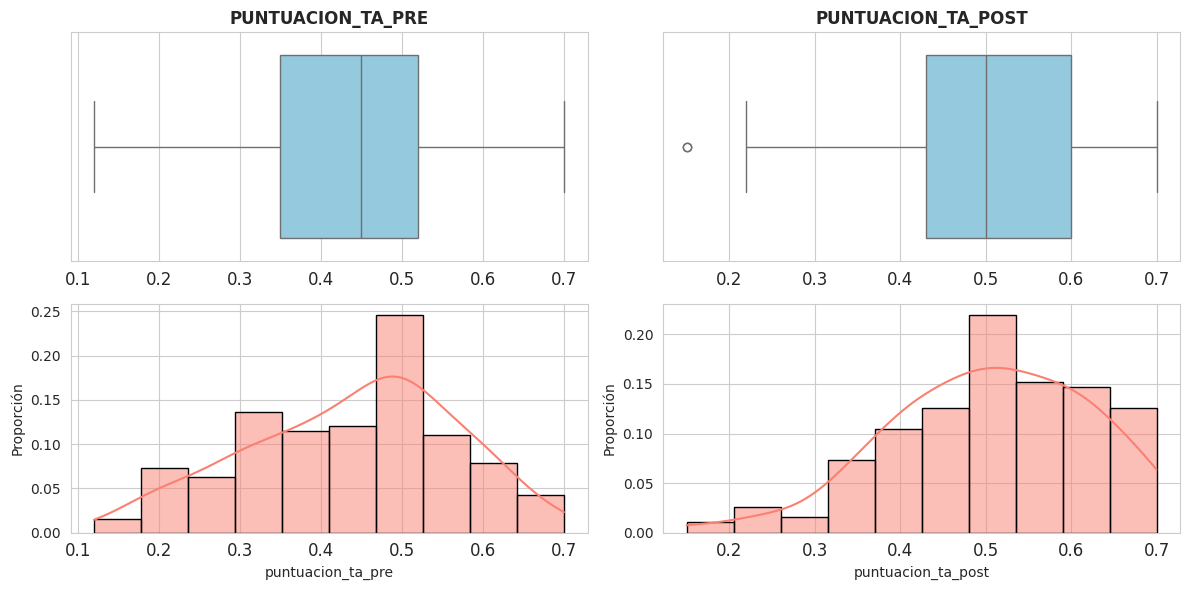

In [174]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = [col for col in forms_quant_cols if 'ta_' in col], 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

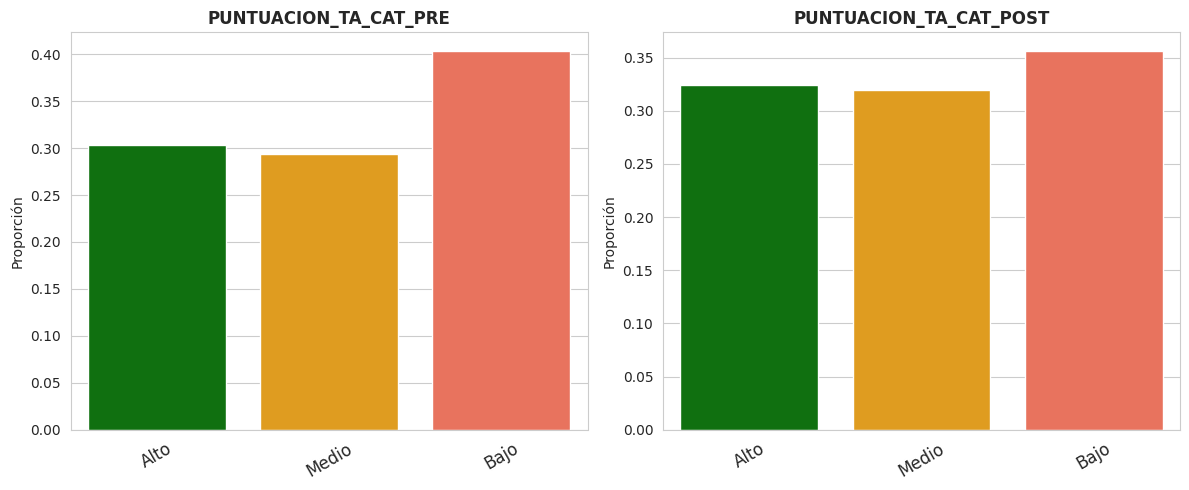

In [175]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = [col for col in forms_cat_cols if 'ta_' in col], 
    max_cols=3, 
    order=['Alto', 'Medio', 'Bajo'],
    palette={'Alto': 'green', 'Medio': 'orange', 'Bajo': 'tomato'},
)

#### TCC-Post

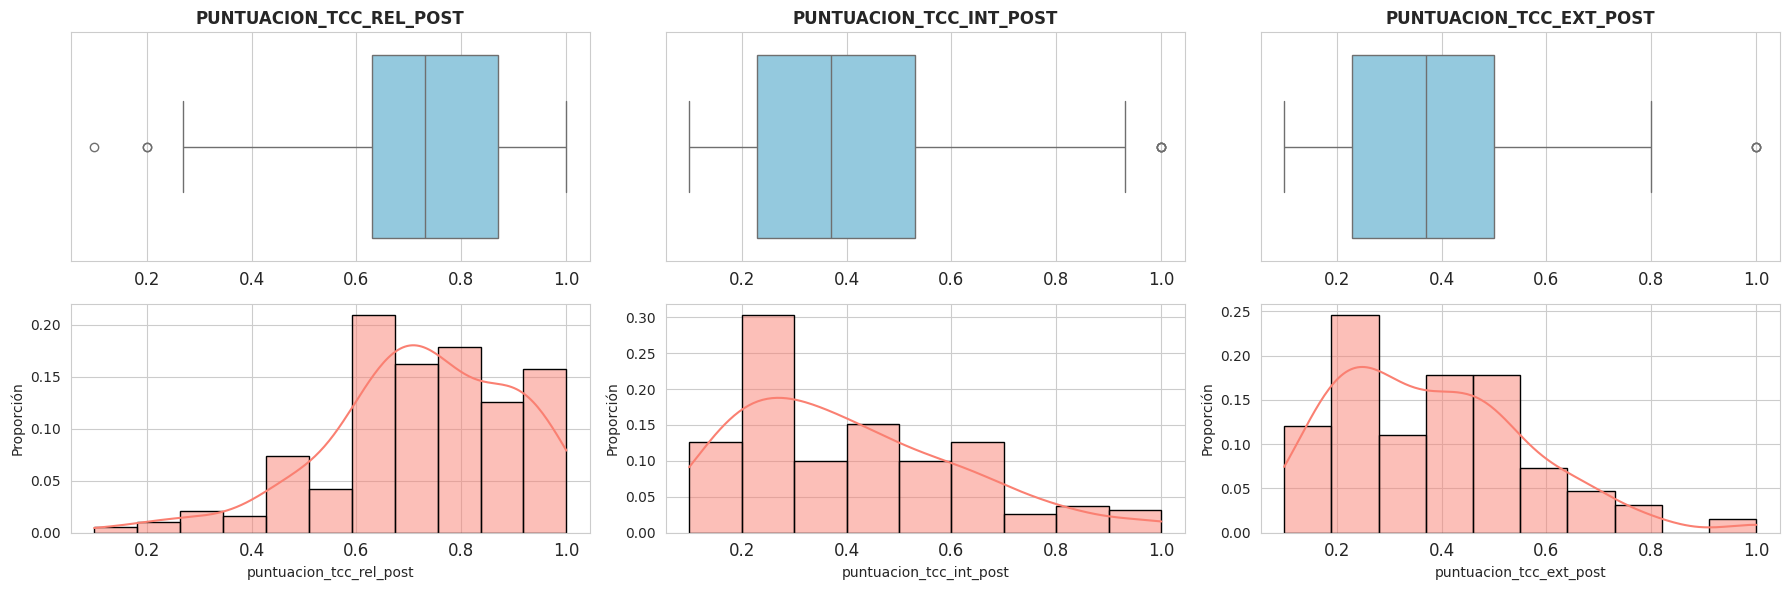

In [176]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = [col for col in forms_quant_cols if 'tcc_' in col], 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

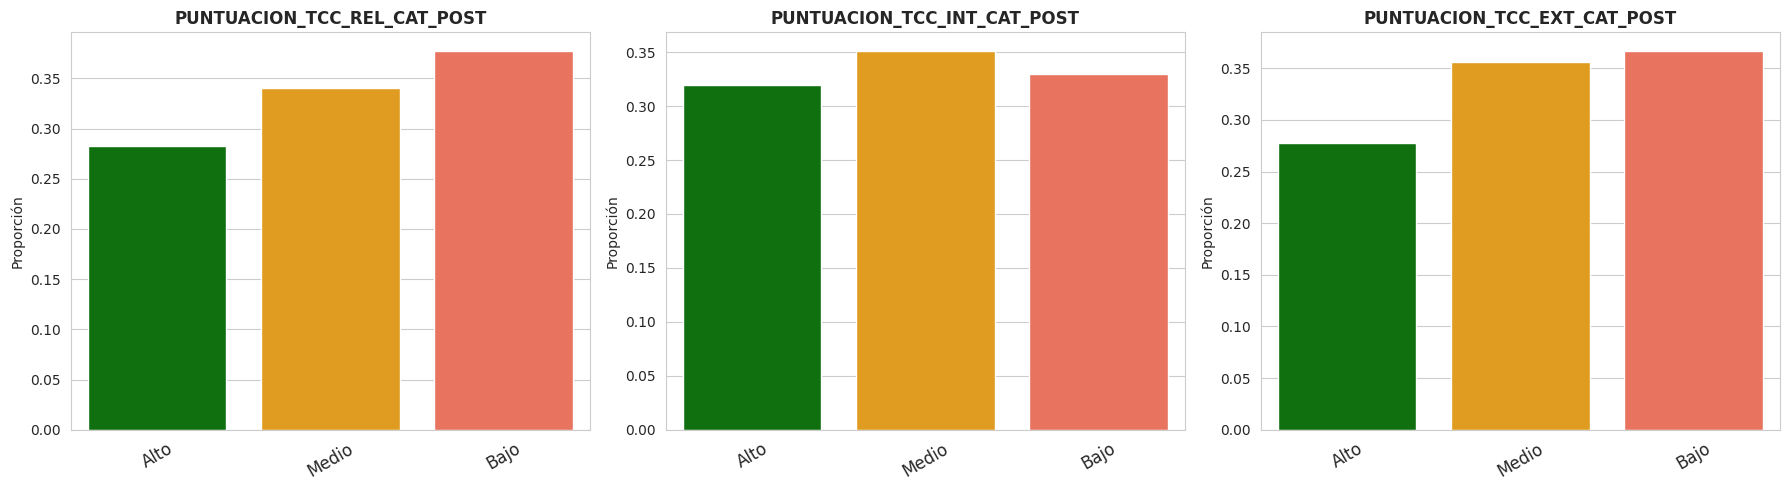

In [177]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = [col for col in forms_cat_cols if 'tcc_' in col], 
    max_cols=3, 
    order=['Alto', 'Medio', 'Bajo'],
    palette={'Alto': 'green', 'Medio': 'orange', 'Bajo': 'tomato'},
)

### Métricas Herramienta

In [178]:
chats_cols = [col for col in forms_interactions_df.columns if col not in forms_cols + context_cols + ['id']]

chats_cat_cols = [col for col in chats_cols if col in cat_cols]
chats_quant_cols = [col for col in chats_cols if col in quant_cols]

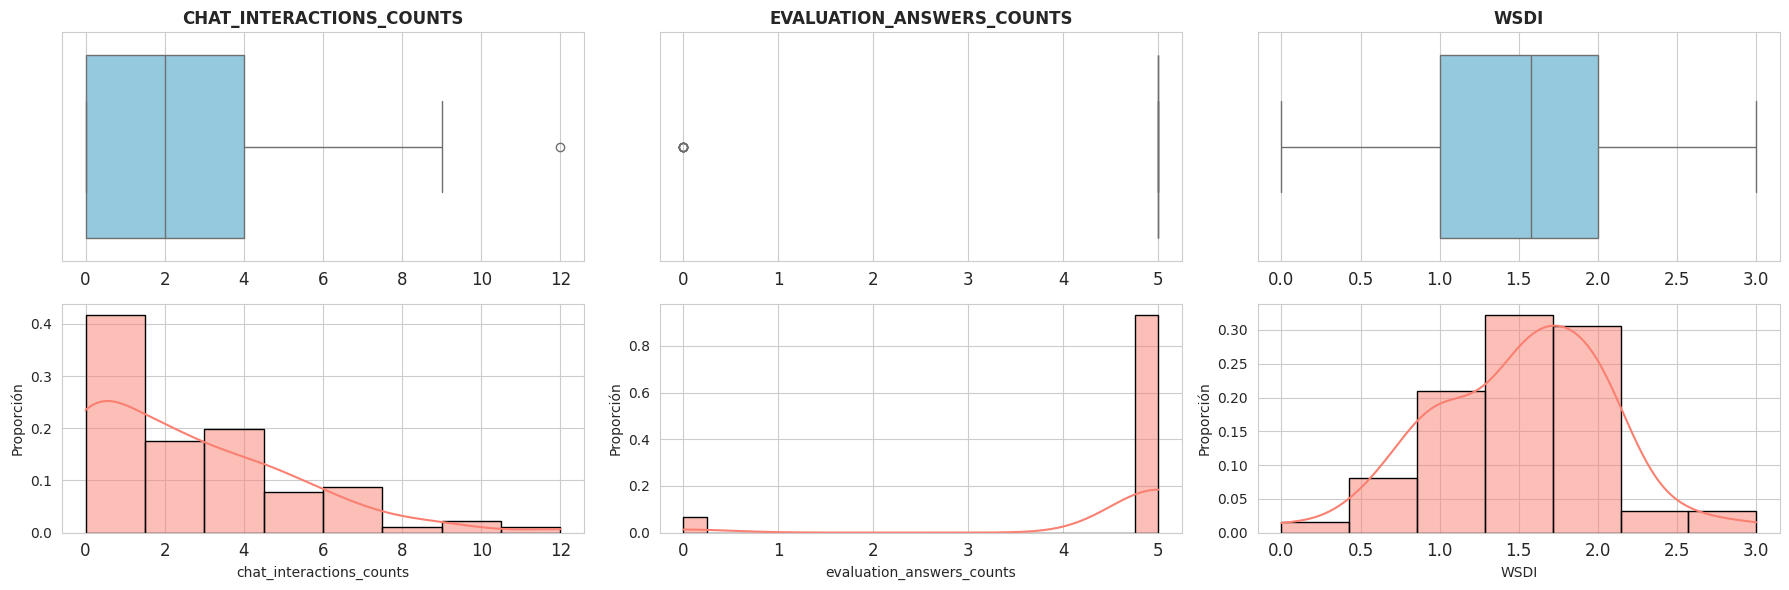

In [179]:
plot_quant_distribution(
    df = forms_interactions_df.filter(pl.col('grupo') == 'experimental'), 
    quant_cols = chats_quant_cols, 
    max_cols=3, box_color="skyblue", hist_color="salmon")


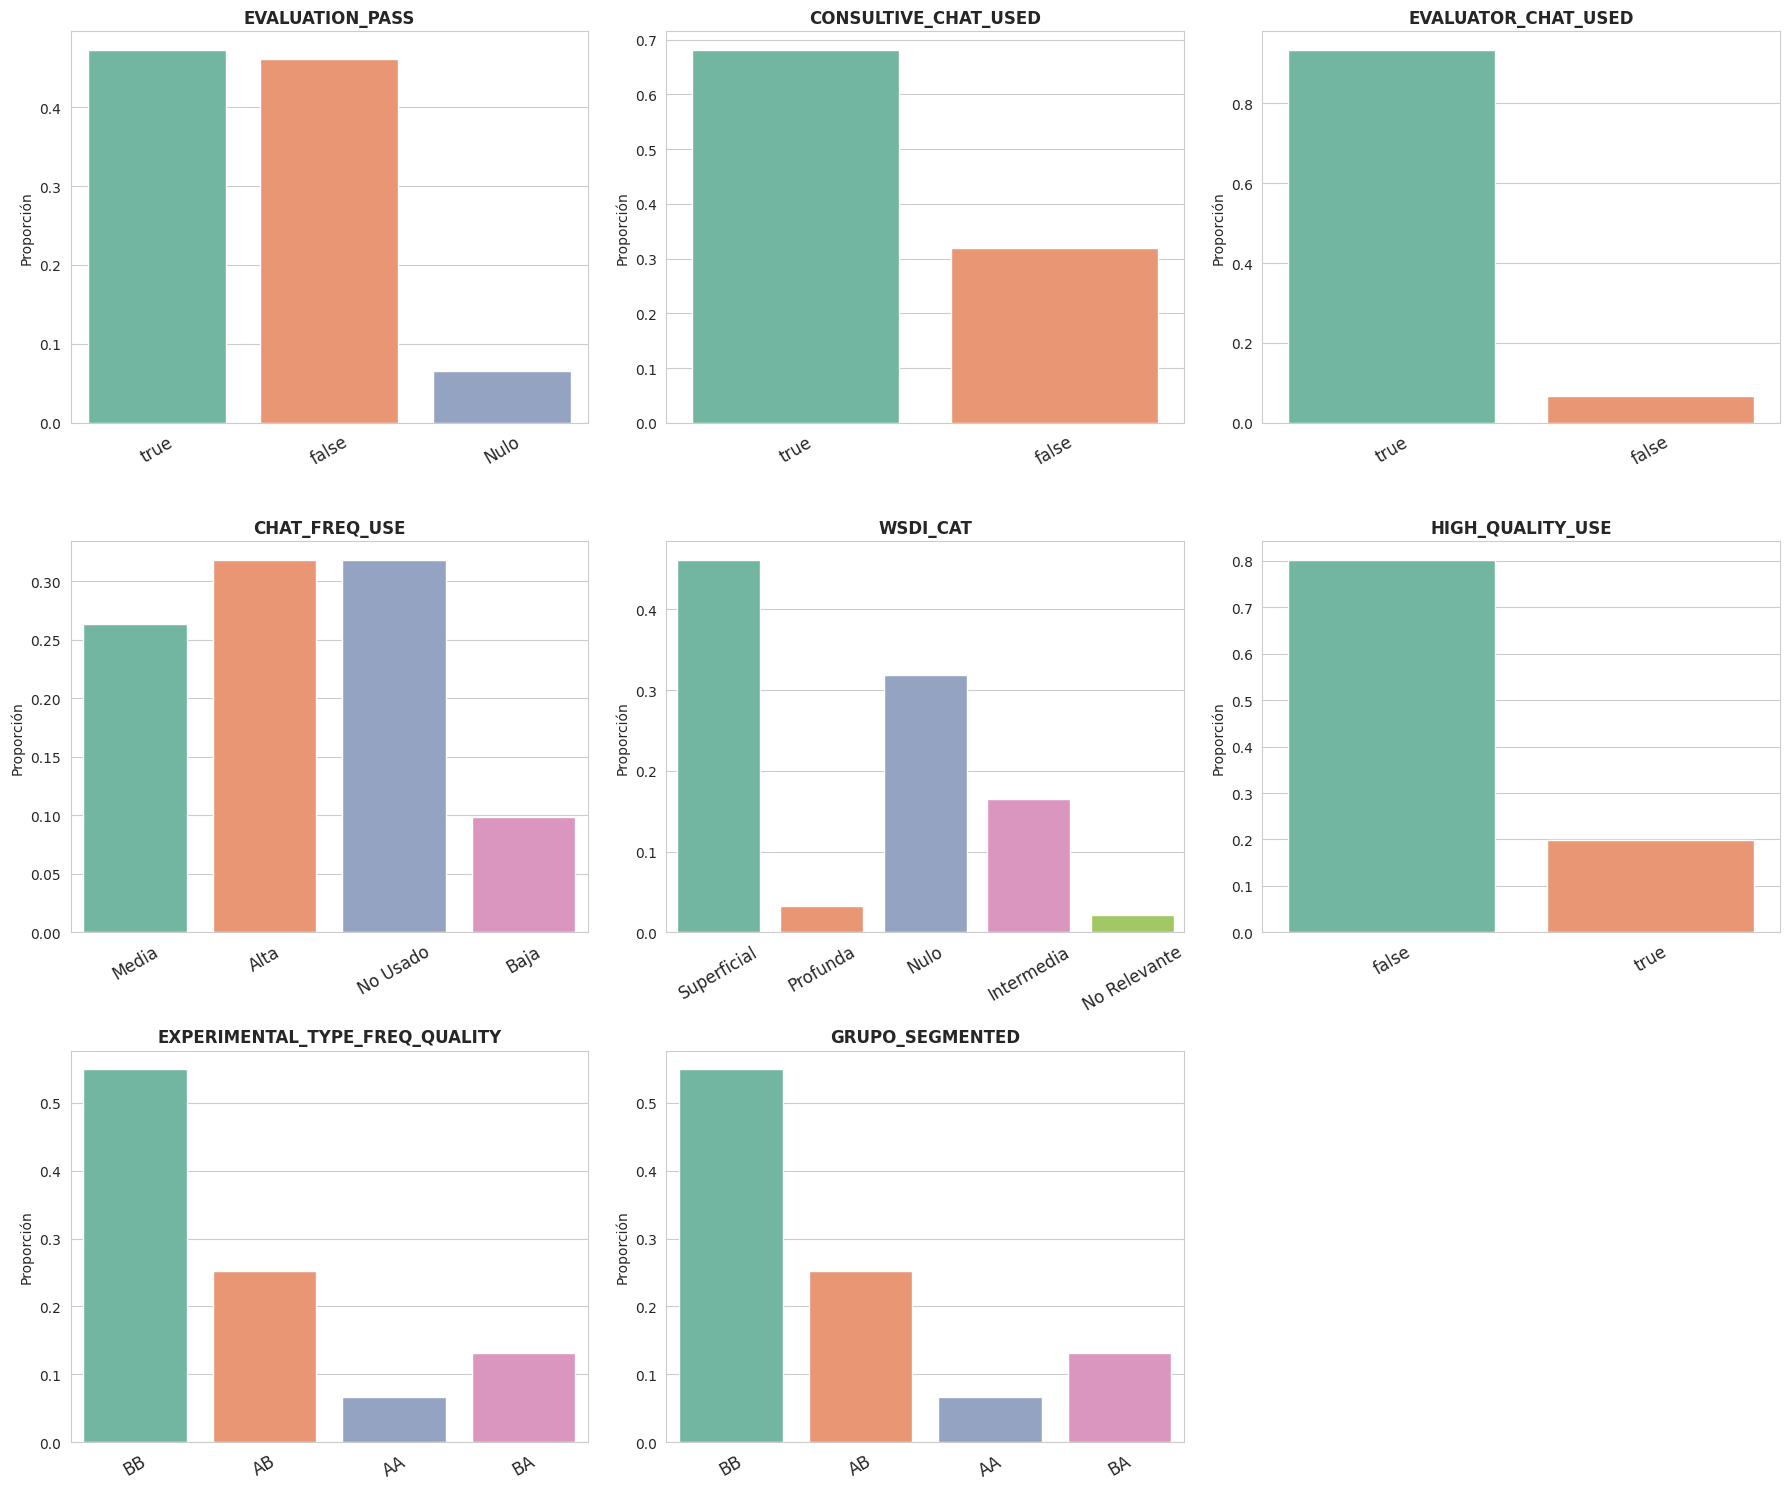

In [180]:
plot_cat_distribution(
    df = forms_interactions_df.filter(
        pl.col('grupo') == 'experimental',
        ~ pl.col('id').is_in(problematic_experimental_ids)
    ), 
    cat_cols = chats_cat_cols, 
    max_cols=3, 
    palette="Set2"
)

---

Segmentación grupo experimental en base a Frecuencia y Calidad de uso de la herramienta (`experimental_type`)

- Frecuencia Alta (`chat_freq_use=='Alta'`) / Calidad Alta (`high_quality_use==True`) (`AA`)
- Frecuencia Baja (`chat_freq_use!='Alta'`) / Calidad Alta (`BA`)
- Frecuencia Alta / Calidad Baja (`high_quality_use==False`) (`AB`)
- Frecuencia Baja / Calidad Baja (`BB`)

Comparar el rendimiento de estos subgrupos experimentals, entre ellos y respecto control.

---
---

In [181]:
forms_interactions_df['grupo'].value_counts()

grupo,count
str,u32
"""experimental""",94
"""control""",97


In [182]:
forms_interactions_df.filter(pl.col('grupo').is_null())

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use,experimental_type_freq_quality,grupo_segmented
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool,str,str


In [183]:
forms_interactions_df

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use,experimental_type_freq_quality,grupo_segmented
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool,str,str
"""RamiroMaeztu-ks0""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,"""Alto""","""Alto""","""Alto""",0.6,0.2,0.8,0.4,"""Medio""","""Bajo""","""Medio""","""Bajo""",1.0,0.4,1.0,1.0,"""Alto""","""Bajo""","""Medio""","""Alto""",0.8,0.43,0.27,"""Medio""","""Medio""","""Bajo""",2,5,true,true,true,"""Media""",1.5,"""Superficial""",false,"""BB""","""BB"""
"""RamiroMaeztu-pu9""","""RamiroMaeztu""","""experimental""",1.0,0.0,1.0,"""Alto""","""Bajo""","""Alto""",0.8,0.48,1.0,0.6,"""Alto""","""Medio""","""Alto""","""Medio""",1.0,0.55,1.0,1.0,"""Alto""","""Medio""","""Medio""","""Alto""",0.2,0.4,0.27,"""Bajo""","""Medio""","""Bajo""",8,5,false,true,true,"""Alta""",1.625,"""Superficial""",false,"""AB""","""AB"""
"""RamiroMaeztu-8jb""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,"""Alto""","""Alto""","""Alto""",0.6,0.45,0.6,0.6,"""Medio""","""Medio""","""Bajo""","""Medio""",1.0,0.4,1.0,1.0,"""Alto""","""Bajo""","""Medio""","""Alto""",0.57,0.6,0.47,"""Bajo""","""Alto""","""Medio""",7,5,true,true,true,"""Alta""",2.571429,"""Profunda""",true,"""AA""","""AA"""
"""RamiroMaeztu-x5e""","""RamiroMaeztu""","""experimental""",0.0,-2.0,0.667,"""Bajo""","""Bajo""","""Medio""",0.6,0.7,0.8,0.4,"""Medio""","""Alto""","""Medio""","""Bajo""",0.6,0.43,0.4,0.8,"""Bajo""","""Bajo""","""Bajo""","""Bajo""",0.63,0.53,0.63,"""Bajo""","""Alto""","""Alto""",0,5,false,false,true,"""No Usado""",null,null,false,"""BB""","""BB"""
"""RamiroMaeztu-80a""","""RamiroMaeztu""","""experimental""",0.5,0.0,0.5,"""Medio""","""Bajo""","""Medio""",0.8,0.52,1.0,0.6,"""Alto""","""Alto""","""Alto""","""Medio""",0.9,0.6,1.0,0.8,"""Medio""","""Alto""","""Medio""","""Bajo""",0.9,0.3,0.27,"""Alto""","""Medio""","""Bajo""",0,5,false,false,true,"""No Usado""",null,null,false,"""BB""","""BB"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Laguna-r45""","""Laguna""","""experimental""",0.0,-1.0,0.5,"""Bajo""","""Bajo""","""Medio""",0.7,0.35,0.8,0.6,"""Medio""","""Bajo""","""Medio""","""Medio""",0.7,0.6,0.6,0.8,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.63,0.47,0.43,"""Bajo""","""Medio""","""Medio""",3,5,true,true,true,"""Media""",1.333333,"""Superficial""",false,"""BB""","""BB"""
"""Laguna-lqw""","""Laguna""","""experimental""",0.4,0.5,0.333,"""Medio""","""Medio""","""Medio""",0.5,0.52,0.6,0.4,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.7,0.6,0.8,0.6,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.93,0.53,0.2,"""Alto""","""Alto""","""Bajo""",2,5,false,true,true,"""Media""",1.0,"""Superficial""",false,"""BB""","""BB"""
"""Laguna-chn""","""Laguna""","""experimental""",0.2,-2.0,0.75,"""Bajo""","""Bajo""","""Alto""",0.5,0.52,0.8,0.2,"""Bajo""","""Alto""","""Medio""","""Bajo""",0.6,0.58,0.4,0.8,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.93,0.27,0.33,"""Alto""","""Bajo""","""Medio""",4,5,false,

In [184]:
forms_interactions_df.group_by(['grupo', 'chat_freq_use']).agg(pl.len())

grupo,chat_freq_use,len
str,str,u32
"""experimental""","""No Usado""",29
"""experimental""",null,3
"""experimental""","""Media""",24
"""control""",null,97
"""experimental""","""Alta""",29
"""experimental""","""Baja""",9


In [185]:
forms_interactions_df.filter((pl.col('grupo') == 'experimental') & (pl.col('evaluation_answers_counts').is_null()))
# Hay que ver que hacer con estos 3 que pertenecen al experimental pero que no se han registrados sus datos de interacción con la herramienta

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use,experimental_type_freq_quality,grupo_segmented
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool,str,str
"""JesusMaria-nre""","""JesusMaria""","""experimental""",-1.0,0.0,0.0,"""Bajo""","""Bajo""","""Bajo""",0.9,0.28,0.8,1.0,"""Alto""","""Bajo""","""Medio""","""Alto""",0.8,0.45,0.8,0.8,"""Medio""","""Bajo""","""Bajo""","""Bajo""",0.6,0.6,0.63,"""Bajo""","""Alto""","""Alto""",null,null,null,null,null,null,null,null,null,null,null
"""JesusMaria-3ci""","""JesusMaria""","""experimental""",0.0,-1.0,0.5,"""Bajo""","""Bajo""","""Medio""",0.7,0.48,0.8,0.6,"""Medio""","""Medio""","""Medio""","""Medio""",0.7,0.6,0.6,0.8,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.83,0.27,0.23,"""Medio""","""Bajo""","""Bajo""",null,null,null,null,null,null,null,null,null,null,null
"""JesusMaria-33y""","""JesusMaria""","""experimental""",-1.25,-3.0,-0.667,"""Bajo""","""Bajo""","""Bajo""",0.6,0.45,0.8,0.4,"""Medio""","""Medio""","""Medio""","""Bajo""",0.1,0.48,0.2,0.0,"""Bajo""","""Medio""","""Bajo""","""Bajo""",0.6,0.63,0.6,"""Bajo""","""Alto""","""Alto""",null,null,null,null,null,null,null,null,null,null,null


In [186]:
forms_interactions_df.filter((pl.col('id') == 'RamiroMaeztu-kya'))

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use,experimental_type_freq_quality,grupo_segmented
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool,str,str


In [187]:
forms_interactions_df.filter((pl.col('grupo') == 'experimental'))

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use,experimental_type_freq_quality,grupo_segmented
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool,str,str
"""RamiroMaeztu-ks0""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,"""Alto""","""Alto""","""Alto""",0.6,0.2,0.8,0.4,"""Medio""","""Bajo""","""Medio""","""Bajo""",1.0,0.4,1.0,1.0,"""Alto""","""Bajo""","""Medio""","""Alto""",0.8,0.43,0.27,"""Medio""","""Medio""","""Bajo""",2,5,true,true,true,"""Media""",1.5,"""Superficial""",false,"""BB""","""BB"""
"""RamiroMaeztu-pu9""","""RamiroMaeztu""","""experimental""",1.0,0.0,1.0,"""Alto""","""Bajo""","""Alto""",0.8,0.48,1.0,0.6,"""Alto""","""Medio""","""Alto""","""Medio""",1.0,0.55,1.0,1.0,"""Alto""","""Medio""","""Medio""","""Alto""",0.2,0.4,0.27,"""Bajo""","""Medio""","""Bajo""",8,5,false,true,true,"""Alta""",1.625,"""Superficial""",false,"""AB""","""AB"""
"""RamiroMaeztu-8jb""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,"""Alto""","""Alto""","""Alto""",0.6,0.45,0.6,0.6,"""Medio""","""Medio""","""Bajo""","""Medio""",1.0,0.4,1.0,1.0,"""Alto""","""Bajo""","""Medio""","""Alto""",0.57,0.6,0.47,"""Bajo""","""Alto""","""Medio""",7,5,true,true,true,"""Alta""",2.571429,"""Profunda""",true,"""AA""","""AA"""
"""RamiroMaeztu-x5e""","""RamiroMaeztu""","""experimental""",0.0,-2.0,0.667,"""Bajo""","""Bajo""","""Medio""",0.6,0.7,0.8,0.4,"""Medio""","""Alto""","""Medio""","""Bajo""",0.6,0.43,0.4,0.8,"""Bajo""","""Bajo""","""Bajo""","""Bajo""",0.63,0.53,0.63,"""Bajo""","""Alto""","""Alto""",0,5,false,false,true,"""No Usado""",null,null,false,"""BB""","""BB"""
"""RamiroMaeztu-80a""","""RamiroMaeztu""","""experimental""",0.5,0.0,0.5,"""Medio""","""Bajo""","""Medio""",0.8,0.52,1.0,0.6,"""Alto""","""Alto""","""Alto""","""Medio""",0.9,0.6,1.0,0.8,"""Medio""","""Alto""","""Medio""","""Bajo""",0.9,0.3,0.27,"""Alto""","""Medio""","""Bajo""",0,5,false,false,true,"""No Usado""",null,null,false,"""BB""","""BB"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Laguna-r45""","""Laguna""","""experimental""",0.0,-1.0,0.5,"""Bajo""","""Bajo""","""Medio""",0.7,0.35,0.8,0.6,"""Medio""","""Bajo""","""Medio""","""Medio""",0.7,0.6,0.6,0.8,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.63,0.47,0.43,"""Bajo""","""Medio""","""Medio""",3,5,true,true,true,"""Media""",1.333333,"""Superficial""",false,"""BB""","""BB"""
"""Laguna-lqw""","""Laguna""","""experimental""",0.4,0.5,0.333,"""Medio""","""Medio""","""Medio""",0.5,0.52,0.6,0.4,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.7,0.6,0.8,0.6,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.93,0.53,0.2,"""Alto""","""Alto""","""Bajo""",2,5,false,true,true,"""Media""",1.0,"""Superficial""",false,"""BB""","""BB"""
"""Laguna-chn""","""Laguna""","""experimental""",0.2,-2.0,0.75,"""Bajo""","""Bajo""","""Alto""",0.5,0.52,0.8,0.2,"""Bajo""","""Alto""","""Medio""","""Bajo""",0.6,0.58,0.4,0.8,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.93,0.27,0.33,"""Alto""","""Bajo""","""Medio""",4,5,false,

In [188]:
forms_interactions_df.filter(pl.col('grupo') == 'control').group_by(['centro', 'WSDI_cat']).agg(pl.len())

centro,WSDI_cat,len
str,str,u32
"""Laguna""",null,25
"""JesusMaria""",null,27
"""JoseGarciaNieto""",null,14
"""RamiroMaeztu""",null,31


In [189]:
forms_interactions_df.filter(
    (pl.col('grupo') == 'experimental') & 
    (pl.col('centro') == 'Laguna')
).group_by(['centro', 'WSDI_cat']).agg(pl.len())

centro,WSDI_cat,len
str,str,u32
"""Laguna""",null,8
"""Laguna""","""No Relevante""",1
"""Laguna""","""Intermedia""",3
"""Laguna""","""Superficial""",11


In [190]:
forms_interactions_df.filter(
    (pl.col('grupo') == 'experimental') &
    (pl.col('centro') == 'Laguna') &
    (~ pl.col('WSDI_cat').is_null()) 
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use,experimental_type_freq_quality,grupo_segmented
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool,str,str
"""Laguna-4kk""","""Laguna""","""experimental""",-1.0,-3.0,-0.333,"""Bajo""","""Bajo""","""Bajo""",0.6,0.55,0.8,0.4,"""Medio""","""Alto""","""Medio""","""Bajo""",0.2,0.15,0.2,0.2,"""Bajo""","""Bajo""","""Bajo""","""Bajo""",0.5,0.6,0.67,"""Bajo""","""Alto""","""Alto""",4,5,true,true,true,"""Alta""",2.0,"""Intermedia""",true,"""AA""","""AA"""
"""Laguna-hxh""","""Laguna""","""experimental""",0.75,0.0,1.0,"""Alto""","""Bajo""","""Alto""",0.6,0.52,1.0,0.2,"""Medio""","""Alto""","""Alto""","""Bajo""",0.9,0.35,0.8,1.0,"""Medio""","""Bajo""","""Bajo""","""Alto""",0.67,0.6,0.67,"""Bajo""","""Alto""","""Alto""",7,5,false,true,true,"""Alta""",0.857143,"""Superficial""",false,"""AB""","""AB"""
"""Laguna-ioy""","""Laguna""","""experimental""",0.833,1.0,0.5,"""Alto""","""Alto""","""Medio""",0.4,0.5,0.2,0.6,"""Bajo""","""Medio""","""Bajo""","""Medio""",0.9,0.38,1.0,0.8,"""Medio""","""Bajo""","""Medio""","""Bajo""",0.43,0.67,0.77,"""Bajo""","""Alto""","""Alto""",4,5,true,true,true,"""Alta""",2.0,"""Intermedia""",true,"""AA""","""AA"""
"""Laguna-2uy""","""Laguna""","""experimental""",0.0,0.0,0.0,"""Bajo""","""Bajo""","""Bajo""",0.8,0.35,0.8,0.8,"""Alto""","""Bajo""","""Medio""","""Alto""",0.8,0.5,0.8,0.8,"""Medio""","""Medio""","""Bajo""","""Bajo""",0.87,0.37,0.2,"""Alto""","""Medio""","""Bajo""",4,5,false,true,true,"""Alta""",1.75,"""Superficial""",false,"""AB""","""AB"""
"""Laguna-rjb""","""Laguna""","""experimental""",0.6,0.0,0.75,"""Medio""","""Bajo""","""Alto""",0.5,0.58,0.8,0.2,"""Bajo""","""Alto""","""Medio""","""Bajo""",0.8,0.7,0.8,0.8,"""Medio""","""Alto""","""Bajo""","""Bajo""",0.9,0.2,0.37,"""Alto""","""Bajo""","""Medio""",7,5,true,true,true,"""Alta""",1.857143,"""Superficial""",false,"""AB""","""AB"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Laguna-chk""","""Laguna""","""experimental""",-3.0,0.0,0.0,"""Bajo""","""Bajo""","""Bajo""",0.9,0.5,1.0,0.8,"""Alto""","""Medio""","""Alto""","""Alto""",0.6,0.48,0.4,0.8,"""Bajo""","""Medio""","""Bajo""","""Bajo""",0.6,0.8,0.8,"""Bajo""","""Alto""","""Alto""",5,5,false,true,true,"""Alta""",1.6,"""Superficial""",false,"""AB""","""AB"""
"""Laguna-4fh""","""Laguna""","""experimental""",0.0,0.0,0.667,"""Bajo""","""Bajo""","""Medio""",0.7,0.4,1.0,0.4,"""Medio""","""Bajo""","""Alto""","""Bajo""",0.7,0.4,0.6,0.8,"""Bajo""","""Bajo""","""Bajo""","""Bajo""",0.5,0.5,0.5,"""Bajo""","""Alto""","""Alto""",2,5,false,true,true,"""Media""",1.0,"""Superficial""",false,"""BB""","""BB"""
"""Laguna-r45""","""Laguna""","""experimental""",0.0,-1.0,0.5,"""Bajo""","""Bajo""","""Medio""",0.7,0.35,0.8,0.6,"""Medio""","""Bajo""","""Medio""","""Medio""",0.7,0.6,0.6,0.8,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.63,0.47,0.43,"""Bajo""","""Medio""","""Medio""",3,5,true,true,true,"""Media""",1.333333,"""Superficial""",false,"""

In [191]:
forms_interactions_df.filter(
    (pl.col('grupo') == 'control') &
    (pl.col('centro') == 'Laguna') &
    (~ pl.col('WSDI_cat').is_null()) 
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use,experimental_type_freq_quality,grupo_segmented
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool,str,str


In [192]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=forms_interactions_df,  
    x='WSDI', 
    y='puntuacion_tc_hake_gain',
    scatter_kws={'alpha':0.5}, # Transparencia para ver puntos solapados
    line_kws={'color':'red'}   # Línea de tendencia
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

NameError: name 'plt' is not defined

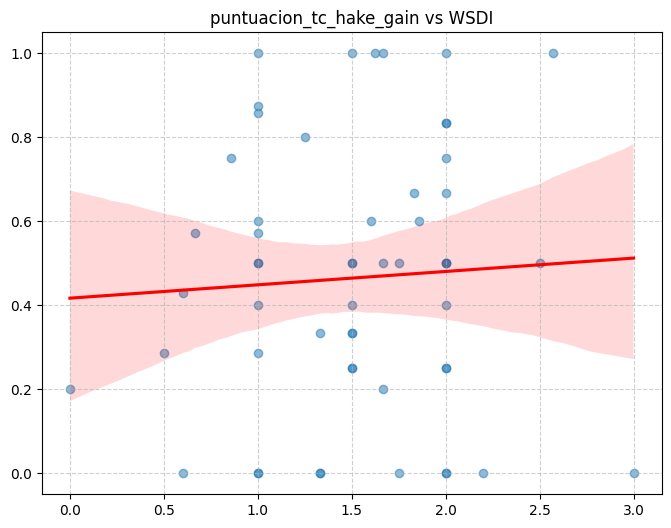

In [ ]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=forms_interactions_df.filter(pl.col('puntuacion_tc_hake_gain') >= 0),  
    x='WSDI', 
    y='puntuacion_tc_hake_gain',
    scatter_kws={'alpha':0.5}, # Transparencia para ver puntos solapados
    line_kws={'color':'red'}   # Línea de tendencia
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

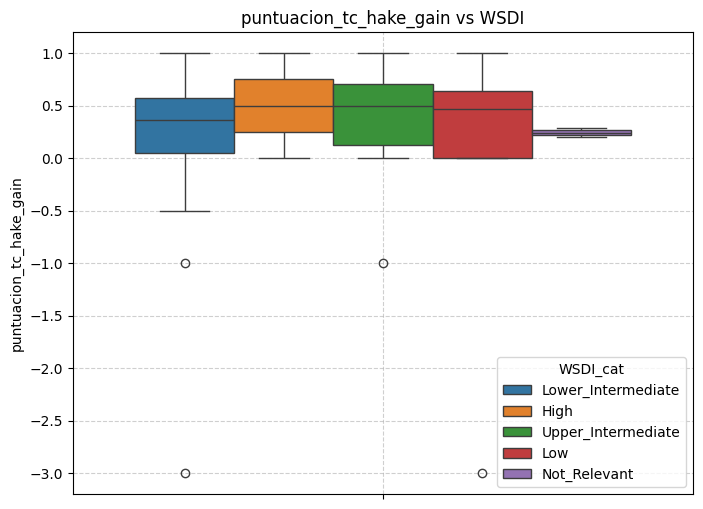

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=forms_interactions_df,  
    y='puntuacion_tc_hake_gain',
    hue='WSDI_cat',
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

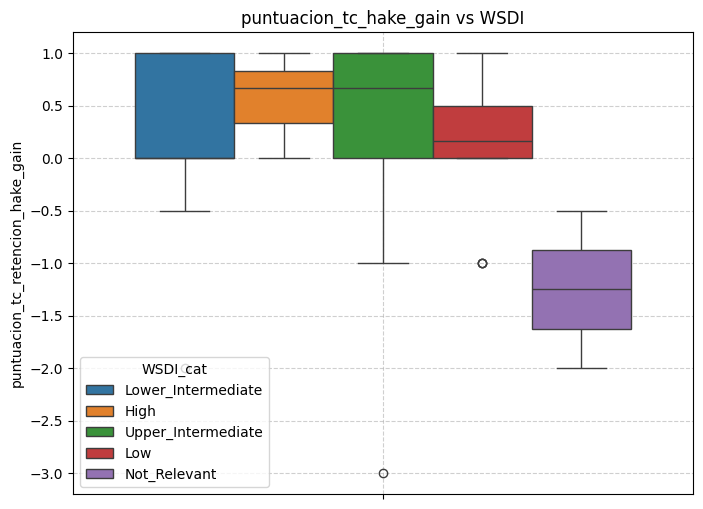

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=forms_interactions_df,  
    y='puntuacion_tc_retencion_hake_gain',
    hue='WSDI_cat',
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

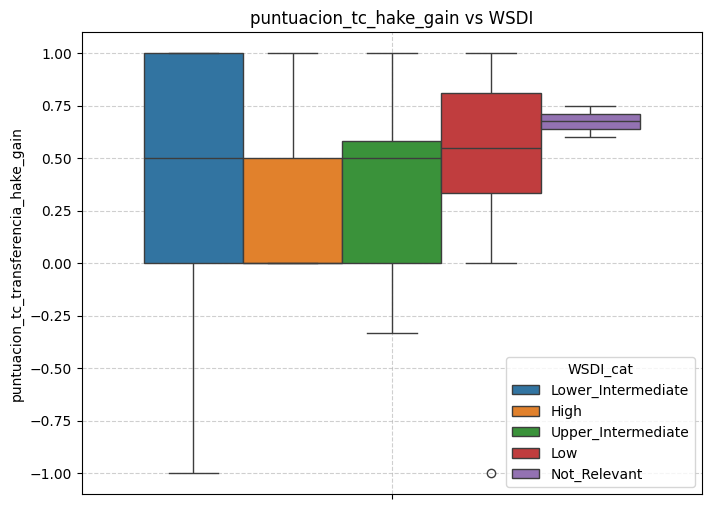

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=forms_interactions_df,  
    y='puntuacion_tc_transferencia_hake_gain',
    hue='WSDI_cat',
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

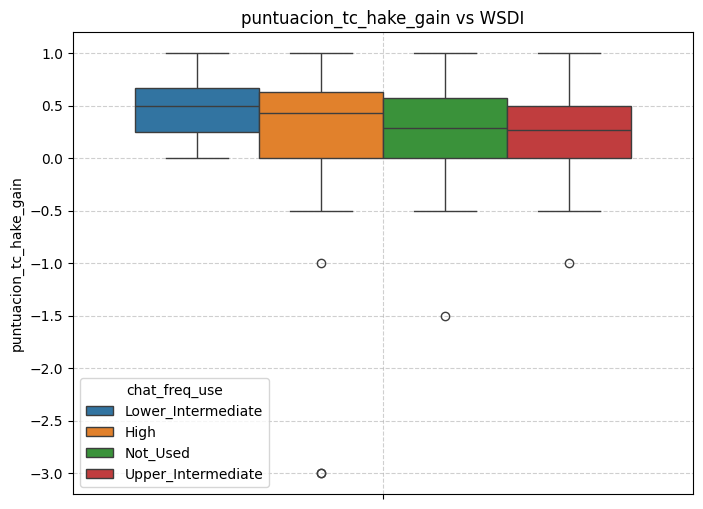

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=forms_interactions_df,  
    y='puntuacion_tc_hake_gain',
    hue='chat_freq_use',
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

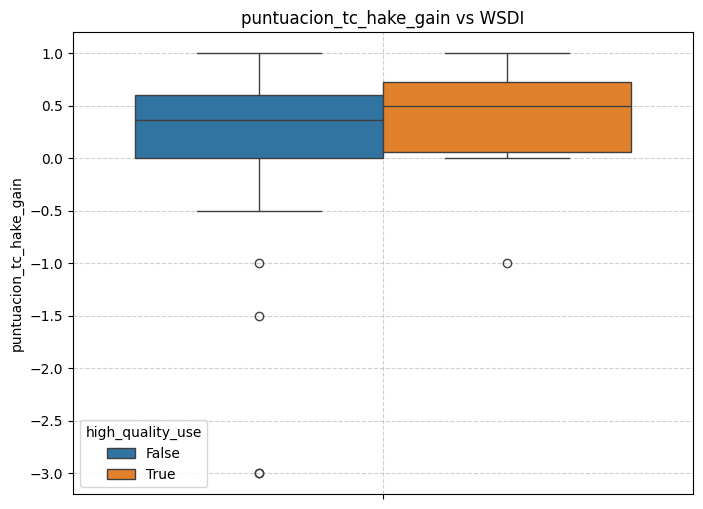

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=forms_interactions_df.filter(pl.col('high_quality_use').is_not_null()),  
    y='puntuacion_tc_hake_gain',
    hue='high_quality_use',
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

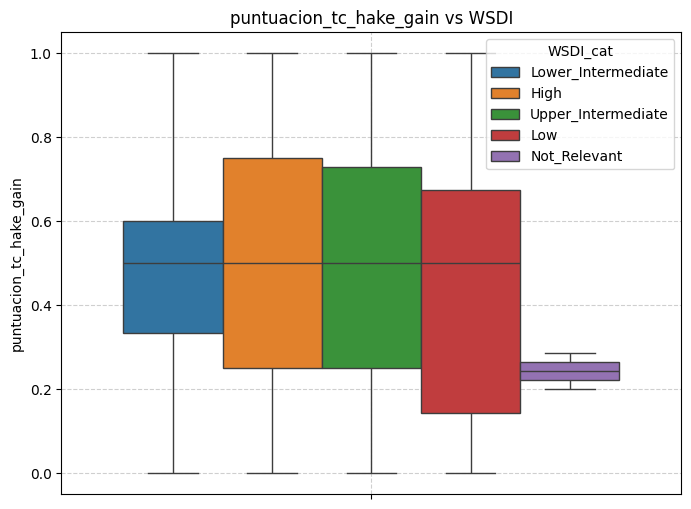

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=forms_interactions_df.filter(pl.col('puntuacion_tc_hake_gain') >= 0),  
    y='puntuacion_tc_hake_gain',
    hue='WSDI_cat',
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

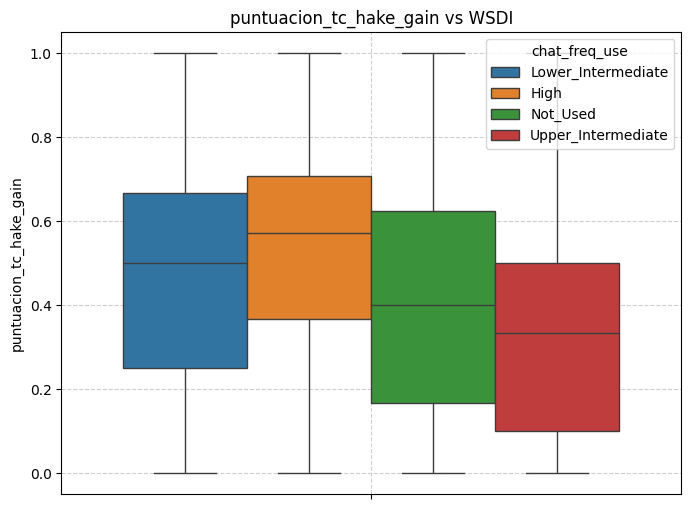

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=forms_interactions_df.filter(pl.col('puntuacion_tc_hake_gain') >= 0),  
    y='puntuacion_tc_hake_gain',
    hue='chat_freq_use',
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

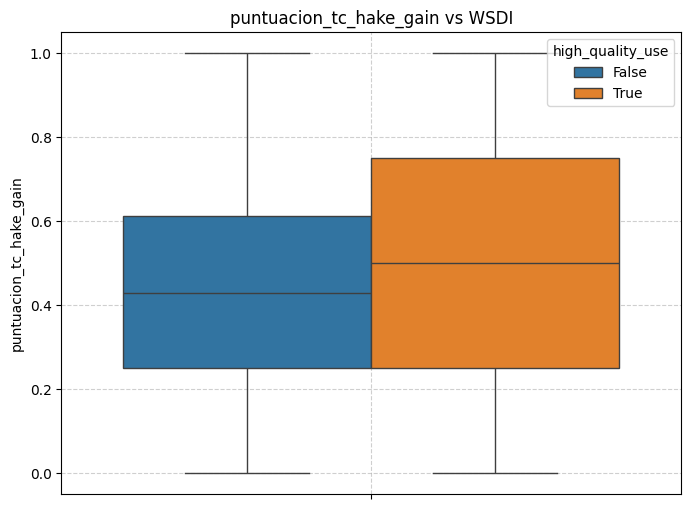

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=forms_interactions_df.filter(pl.col('high_quality_use').is_not_null()).filter(pl.col('puntuacion_tc_hake_gain') >= 0),  
    y='puntuacion_tc_hake_gain',
    hue='high_quality_use',
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()